# Understanding the Governed Data World Pt1

Before proceeding with any analysis, we need to first understand what datasets we are dealing with. And refering to `analysis\dev_full_offline_investigation\surface_atlas.md`, we can see 7 classes:

Surface classes
- `traffic`: canonical behavioural traffic eligible for platform ingestion
- `context`: join or enrichment surface used to understand traffic
- `truth`: offline outcome or supervisory surface
- `telemetry`: audit or operational evidence, not business traffic


Time-safety classes
- `rtdl_safe`: eligible as decision-time context if used correctly
- `offline_only`: batch, truth, or closure-dependent surface; never live-decision input
- `not_traffic`: should not be treated as business traffic even if event-like

But first, we will examine the data as it moves from Layer-1 to Layer-3 so as to get an understanding of it before we begin investigating the surface classes.

Here is the [Layer-Layer view of Data Engine](../../../../docs/design/data-engine/data-engine-segment-synthesis-flow.png)

![data-engine-layer-layer-view](../../../../docs/design/data-engine/data-engine-segment-synthesis-flow.png)


At a high level, the Data Engine moves from **world construction** to **activity realisation** to **behaviour, fraud, and truth**.

- **Layer 1 (`1A` to `3B`) builds the governed world.**
  - `1A` decides the merchant and outlet footprint: how many outlets exist and in which countries.
  - `1B` places those outlets into concrete geography.
  - `2A` assigns civil time zones and DST/legal-time behaviour.
  - `2B` builds the routing fabric that later traffic can use.
  - `3A` refines merchants across intra-country zones where needed.
  - `3B` adds the virtual/edge world for merchants that operate through network edges rather than physical sites.

- **Layer 2 (`5A`, `5B`) brings that world to life over time.**
  - `5A` creates intensity shapes: when and how strongly activity should happen across merchants, classes, channels, zones, and scenarios.
  - `5B` turns those intensities into actual arrival skeletons, producing the first event-like activity surface, `arrival_events_5B`.

- **Layer 3 (`6A`, `6B`) turns arrivals into an entity-rich behavioural world with fraud and truth.**
  - `6A` builds the entity layer: parties, accounts, instruments, devices, IPs, and fraud-role posture.
  - `6B` attaches those entities to arrivals, generates behavioural event streams and flow anchors, overlays fraud campaigns, and then emits the truth products: event labels, flow truth, bank view, and case timelines.

The important interpretation is this: the engine first creates the **world**, then the **clock of activity**, then the **actors and behaviour**, and finally the **fraud/case truth** that the platform consumes offline or operationally. Also, `4A/4B` are not standalone production layers now; their concerns were folded in as cross-cutting gate, validation, and audit disciplines across the earlier segments. See [data_engine_interface.md](/c:/Users/LEGION/Documents/Data%20Science/Python%20&%20R%20Scripts/fraud-detection-system/docs/model_spec/data-engine/interface_pack/data_engine_interface.md), [narrative_1A-to-3B.md](/c:/Users/LEGION/Documents/Data%20Science/Python%20&%20R%20Scripts/fraud-detection-system/docs/model_spec/data-engine/layer-1/narrative/narrative_1A-to-3B.md), and [narrative_5A-and-5B.md](/c:/Users/LEGION/Documents/Data%20Science/Python%20&%20R%20Scripts/fraud-detection-system/docs/model_spec/data-engine/layer-2/narrative/narrative_5A-and-5B.md).


## Notebook Setup

In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns

# Widen the notebook display so summary tables are easier to inspect while reading.
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 220)


In [2]:
# Walk upward from the current directory until we hit the repo root.
# We identify the root by the presence of AGENTS.md and the reference folder.
def find_repo_root(start: str | None = None) -> Path:
    here = Path(start or os.getcwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "reference").exists():
            return candidate
    raise FileNotFoundError("Could not locate repo root")


# Resolve the repo root once so every later path can be expressed relative to it.
ROOT = find_repo_root()
# Point to the exact merchant-universe parquet sealed into the current investigation basis.
transaction_schema_merchant_ids_path = ROOT / "reference" / "layer1" / "transaction_schema_merchant_ids" / "2026-01-03" / "transaction_schema_merchant_ids.parquet"
# Keep the associated bootstrap policy nearby because it is part of the sealed input story.
transaction_schema_bootstrap_policy_path = ROOT / "config" / "layer1" / "1A" / "ingress" / "transaction_schema_merchant_ids.bootstrap.yaml"
# These are the other sealed S0 external data artefacts we need for the merchant-country explanation.
iso3166_canonical_2024_path = ROOT / "reference" / "iso" / "iso3166_canonical" / "2024-12-31" / "iso3166.parquet"
world_bank_gdp_per_capita_20250415_path = ROOT / "reference" / "economic" / "world_bank_gdp_per_capita" / "2025-04-15" / "gdp.parquet"
gdp_bucket_map_2024_path = ROOT / "reference" / "economic" / "gdp_bucket_map" / "2024" / "gdp_bucket_map.parquet"

merchant_ids_df = pd.read_parquet(transaction_schema_merchant_ids_path)
iso3166_df = pd.read_parquet(iso3166_canonical_2024_path)
gdp_df = pd.read_parquet(world_bank_gdp_per_capita_20250415_path)
gdp_bucket_df = pd.read_parquet(gdp_bucket_map_2024_path)

# Echo the exact artefacts we are analysing so the notebook remains tied to the sealed run inputs.
print(f"transaction_schema_merchant_ids_path: {transaction_schema_merchant_ids_path}")
print(f"bootstrap_policy_path: {transaction_schema_bootstrap_policy_path}")
print(f"iso3166_canonical_2024_path: {iso3166_canonical_2024_path}")
print(f"world_bank_gdp_per_capita_20250415_path: {world_bank_gdp_per_capita_20250415_path}")
print(f"gdp_bucket_map_2024_path: {gdp_bucket_map_2024_path}")
print(f"merchant_ids_shape: {merchant_ids_df.shape}")
print(f"iso3166_shape: {iso3166_df.shape}")
print(f"gdp_shape: {gdp_df.shape}")
print(f"gdp_bucket_shape: {gdp_bucket_df.shape}")


transaction_schema_merchant_ids_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\reference\layer1\transaction_schema_merchant_ids\2026-01-03\transaction_schema_merchant_ids.parquet
bootstrap_policy_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\config\layer1\1A\ingress\transaction_schema_merchant_ids.bootstrap.yaml
iso3166_canonical_2024_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\reference\iso\iso3166_canonical\2024-12-31\iso3166.parquet
world_bank_gdp_per_capita_20250415_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\reference\economic\world_bank_gdp_per_capita\2025-04-15\gdp.parquet
gdp_bucket_map_2024_path: C:\Users\LEGION\Documents\Data Science\Python & R Scripts\fraud-detection-system\reference\economic\gdp_bucket_map\2024\gdp_bucket_map.parquet
merchant_ids_shape: (10000, 4)
iso3166_shape: (251, 8)
gdp_shape: (190, 4)
gd

## Layer 1
[view-img](../../../../docs/design/data-engine/layer-1/layer-1-state-synthesis-flow.png)
![layer-1-view](../../../../docs/design/data-engine/layer-1/layer-1-state-synthesis-flow.png)

### Segment 1A

> "`1A` is the segment that turns a sealed merchant world into a certified outlet-world authority through deterministic lineage control, branch-gated stochastic realism, explicit cross-border order authority, deterministic country-weight and allocation bridges, fingerprint-scoped egress, and final replay validation."

1A Synthesis doc: [here](../../../../docs/design/data-engine/layer-1/1A/1A-state-synthesis.md)

![1A-overview-design-flow.png](../../../../docs/design/data-engine/layer-1/1A/1A-overview-design-flow.png)
[1A-overview-design-flow.png](../../../../docs/design/data-engine/layer-1/1A/1A-overview-design-flow.png)

#### Segment 1A.S0

![1A-S0-design-flow](../../../../docs/design/data-engine/layer-1/1A/1A-S0-design-flow.png)
[1A-S0-design-flow](../../../../docs/design/data-engine/layer-1/1A/1A-S0-design-flow.png)

1A.S0:
> "So `S0` is best understood as the lineage and precompute authority of `1A`, not just a preamble."

For `1A`, `S0` is not the whole segment. It does three things:
- seals the canonical external data universe
- opens and hashes the governed artefacts that define the lawful `1A` run
- emits the sealed `1A` input world and a small set of prep or diagnostic surfaces

A: **External data brought in at `S0.1`**
- `transaction_schema_merchant_ids`: ingress merchant universe
- `iso3166_canonical_2024`: canonical ISO country list
- `world_bank_gdp_per_capita_20250415`: pinned GDP-per-capita vintage
- `gdp_bucket_map_2024`: pinned GDP bucket map

B: **Governed artefacts opened at `S0.2`**
- `hurdle_coefficients.yaml`
- `nb_dispersion_coefficients.yaml`
- `crossborder_hyperparams.yaml`
- `ccy_smoothing_params.yaml`
- `s6_selection_policy.yaml`
- `policy.s3.rule_ladder.yaml`
- `policy.s3.base_weight.yaml` when enabled
- `policy.s3.thresholds.yaml` when referenced
- `transaction_schema_merchant_ids_bootstrap_policy`
- `settlement_shares_2024Q4`
- `ccy_country_shares_2024Q4`
- `numeric_policy_profile`
- `math_profile_manifest`
- optional `static.currency_to_country.map.json` when referenced by policy

C: **Datasets produced by `S0`**
- `sealed_inputs_1A`
- `s0_gate_receipt_1A`
- `crossborder_eligibility_flags`
- optional `crossborder_features`
- optional `hurdle_pi_probs`
- optionally materialised `hurdle_design_matrix`

What matters for the investigation at this stage is the distinction:
- `S0.1` tells us what external data world `1A` begins from
- `S0.2` tells us which governed model, policy, and numeric artefacts define the lawful run
- the `S0` outputs tell us what sealed world later `1A` states are allowed to consume


A.1: `transaction_schema_merchant_ids`
- version: `2026-01-03`
- path: `reference/layer1/transaction_schema_merchant_ids/2026-01-03/transaction_schema_merchant_ids.parquet`
- sha256: `df2f940f061a09a018e133828c9b7b2e7e442a1052b5c0105ef927e2b7c696e8`
- associated bootstrap policy: `config/layer1/1A/ingress/transaction_schema_merchant_ids.bootstrap.yaml`
- bootstrap policy sha256: `f99aace1899982bda221596b64fecd6ff240dd62d8be081159eb1c457765c6c7`

##### Initial analysis of `transaction_schema_merchant_ids`

We start with a bounded statistical summary of the merchant universe:
- shape
- schema
- nulls
- uniqueness
- distributions across `channel`, `home_country_iso`, and `mcc`


In [3]:
# Show a few rows first so we can see the raw row shape before computing summaries.
merchant_ids_df.head(10)

,merchant_id,mcc,channel,home_country_iso
0,1694081450446801,5561,card_present,LU
1,2697116941085629,4789,card_not_present,LU
2,3361754771680650,7996,card_present,ES
3,9012167658511518,4411,card_present,PF
4,10766668736889901,7631,card_present,JP
5,12629669232507242,8062,card_not_present,MC
6,14291053214586959,7699,card_not_present,FO
7,18638034984233531,4225,card_present,EC
8,19498508446557154,7534,card_present,IL
9,23202490577169710,7299,card_present,CA


In [4]:
merchant_ids_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   merchant_id       10000 non-null  uint64
 1   mcc               10000 non-null  int32 
 2   channel           10000 non-null  object
 3   home_country_iso  10000 non-null  object
dtypes: int32(1), object(2), uint64(1)
memory usage: 273.6+ KB


Build a compact column-level profile.

In [5]:
# This lets us see data types, null exposure, and cardinality in one table.
pd.DataFrame(
    {
        # Column names in their dataset order.
        "column": merchant_ids_df.columns,
        # Pandas dtypes tell us how the parquet landed in memory.
        "dtype": merchant_ids_df.dtypes.astype(str).values,
        # Absolute null counts highlight missingness immediately.
        "null_count": merchant_ids_df.isna().sum().values,
        # Null percentage makes the counts comparable across columns.
        "null_pct": (merchant_ids_df.isna().mean().mul(100).round(2)).values,
        # Distinct counts show the effective breadth of each field.
        "distinct_count": merchant_ids_df.nunique(dropna=False).values,
    }
)

,column,dtype,null_count,null_pct,distinct_count
0,merchant_id,uint64,0,0.0,10000
1,mcc,int32,0,0.0,290
2,channel,object,0,0.0,2
3,home_country_iso,object,0,0.0,190


Capture the first structural checks for the dataset.

In [6]:
# These tell us how big the merchant universe is and whether merchant_id behaves like a true key.
pd.DataFrame(
    [
        # Total row count in the merchant universe.
        {"check": "row_count", "value": len(merchant_ids_df)},
        # Distinct merchant IDs should match row count if merchant_id is unique.
        {"check": "merchant_id_distinct", "value": merchant_ids_df["merchant_id"].nunique()},
        # Duplicate merchant IDs would be an immediate structural concern for this ingress table.
        {"check": "merchant_id_duplicate_rows", "value": int(merchant_ids_df["merchant_id"].duplicated().sum())},
        # Number of represented home countries.
        {"check": "country_distinct", "value": merchant_ids_df["home_country_iso"].nunique()},
        # Number of represented MCC categories.
        {"check": "mcc_distinct", "value": merchant_ids_df["mcc"].nunique()},
        # Number of channel values present in the dataset.
        {"check": "channel_distinct", "value": merchant_ids_df["channel"].nunique()},
    ]
)

,check,value
0,row_count,10000
1,merchant_id_distinct,10000
2,merchant_id_duplicate_rows,0
3,country_distinct,190
4,mcc_distinct,290
5,channel_distinct,2


In [7]:
# Count merchants by channel to see the overall CP vs CNP split.
merchant_ids_df["channel"].value_counts(dropna=False).rename_axis("channel").reset_index(name="merchant_count")

,channel,merchant_count
0,card_present,7473
1,card_not_present,2527


List the most represented home countries.

In [8]:
# We limit to the top 20 so the first read stays compact.
merchant_ids_df["home_country_iso"].value_counts(dropna=False).head(20).rename_axis("home_country_iso").reset_index(name="merchant_count")

,home_country_iso,merchant_count
0,MC,800
1,BM,436
2,LU,379
3,IE,337
4,GH,315
5,CH,304
6,NO,262
7,SG,238
8,AU,212
9,US,211


Measure how much of the full merchant universe is captured by the leading countries.

In [9]:
# Rank countries by merchant count so we can see how quickly the merchant universe concentrates.
country_concentration_df = merchant_ids_df["home_country_iso"].value_counts(dropna=False).rename_axis("home_country_iso").reset_index(name="merchant_count")

# Convert raw counts into percentage share of the full merchant universe.
country_concentration_df["merchant_share_pct"] = (country_concentration_df["merchant_count"] / len(merchant_ids_df) * 100).round(2)

# Cumulative share shows how much of the universe is covered as we move down the ranked list.
country_concentration_df["cumulative_share_pct"] = country_concentration_df["merchant_share_pct"].cumsum().round(2)

# Inspect the leading rows first, then read off top-5, top-10, top-20 style coverage from the cumulative column.
country_concentration_df.head(20)

,home_country_iso,merchant_count,merchant_share_pct,cumulative_share_pct
0,MC,800,8.00,8.00
1,BM,436,4.36,12.36
2,LU,379,3.79,16.15
3,IE,337,3.37,19.52
4,GH,315,3.15,22.67
5,CH,304,3.04,25.71
6,NO,262,2.62,28.33
7,SG,238,2.38,30.71
8,AU,212,2.12,32.83
9,US,211,2.11,34.94


Visualise country concentration with a Pareto chart so we can see both rank order and cumulative coverage together.

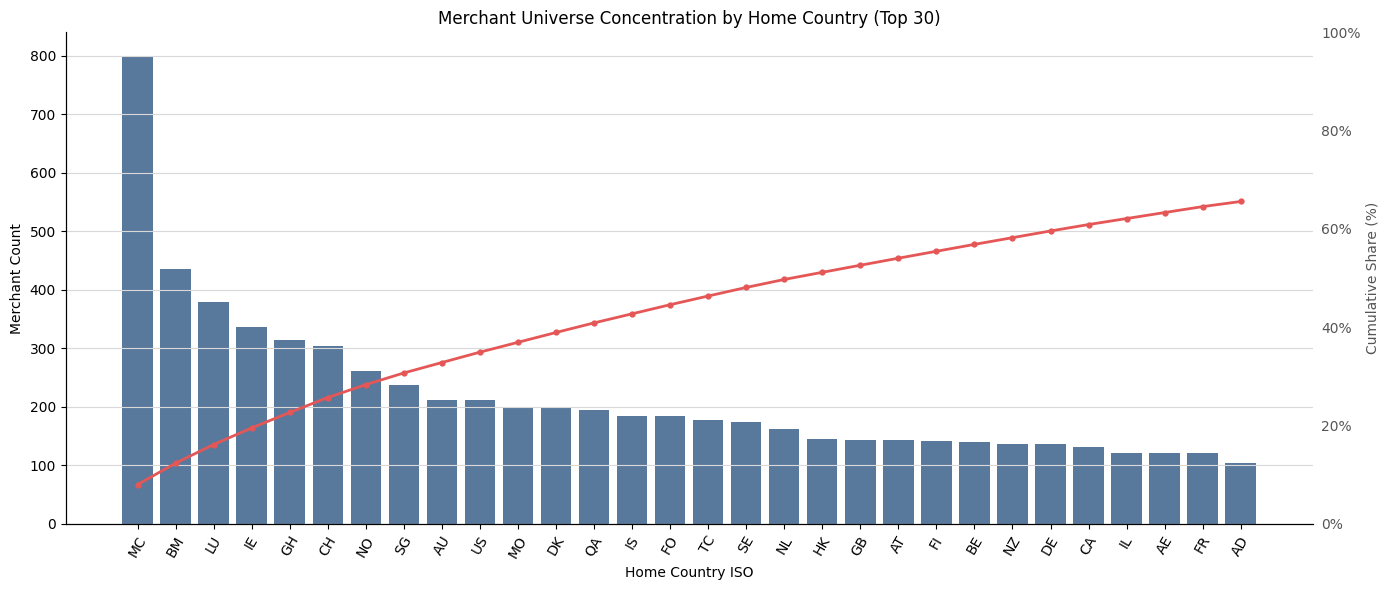

In [10]:
# Focus the chart on the top 30 countries so the x-axis stays readable.
country_plot_df = country_concentration_df.head(30).copy()

# Create the bar axis first because merchant count is the primary scale we want the eye to read.
fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=country_plot_df, x="home_country_iso", y="merchant_count", color="#4C78A8", ax=ax1)
ax1.set_title("Merchant Universe Concentration by Home Country (Top 30)")
ax1.set_xlabel("Home Country ISO")
ax1.set_ylabel("Merchant Count")
ax1.tick_params(axis="x", rotation=60)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax1.grid(axis="x", visible=False)

# Add the cumulative-share line on a secondary axis, but keep that axis visually subordinate.
ax2 = ax1.twinx()
ax2.plot(
    range(len(country_plot_df)),
    country_plot_df["cumulative_share_pct"],
    color="#E45756",
    marker="o",
    markersize=3.5,
    linewidth=2,
)
ax2.set_ylabel("Cumulative Share (%)", color="#555555")
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(PercentFormatter(100))
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="y", colors="#555555", length=0, pad=6)
ax2.grid(False)

plt.tight_layout()
plt.show()


**Interpretation:** Country concentration is much sharper than the raw merchant-count table first suggests. The Pareto curve tells us that the merchant seed world is not spread evenly across home-country jurisdictions; a small leading set carries a disproportionate share of the universe.

**Metrics behind the plot:** `190` distinct countries are present, but the top `5` already account for `22.67%` of the merchant universe, the top `10` for `34.94%`, the top `20` for `52.62%`, and the top `30` for `65.59%`. The leading jurisdiction alone (`MC`) contributes `800` merchants, or `8.00%` of the full `10,000`-merchant seed.

We now have a cleaner explanation for why this happens. Most of the heavy-country shape is deliberate: the merchant universe is generated from a GDP-per-capita-heavy allocation policy with heavy-tail and regional boosts, so affluent and boosted markets such as `MC`, `BM`, `LU`, and `IE` are expected to rise toward the top. One visible outlier, `GH`, is different: it is materially amplified by the builder's residual-allocation step rather than by the intended policy shape alone.

That matters for the later fraud and platform story because country is going to act as a hidden weight in several downstream surfaces. Routing geography, legal-time posture, cross-border opportunity, and even campaign concentration can all inherit this early imbalance. So this is not just a descriptive country chart; it is an early explanation boundary for how much of the downstream world is policy-shaped versus builder-shaped.

**Validation note:** The top-country concentration is real, but it should not be treated as one undifferentiated phenomenon. The rich-country cluster is mostly a governed consequence of the merchant-allocation policy, while `GH` is a builder-side allocation artefact caused by the residual reconciliation logic.

That distinction matters because `MC`, `BM`, `LU`, `IE`, and `GH` together account for `2,267` merchants (`22.67%` of the seed world), but they do not all mean the same thing analytically. If we later observe heavy traffic, cases, or labels from those countries, we should remember that some of that weight is intentional policy shape and some of it is implementation side-effect.

The detailed reconstruction is in [transaction_schema_country_concentration_explanation.md](../../../../analysis/dev_full_offline_investigation/00_investigation/watson_workbench/notes/transaction_schema_country_concentration_explanation.md).

---


List the most represented MCC codes.

In [11]:
# This shows whether the merchant universe is broadly spread or heavily concentrated in a few categories.
merchant_ids_df["mcc"].value_counts(dropna=False).head(20).rename_axis("mcc").reset_index(name="merchant_count")

,mcc,merchant_count
0,8651,52
1,7922,52
2,5992,51
3,5193,50
4,5937,49
5,7299,49
6,7011,47
7,4812,47
8,5521,47
9,7801,47


Measure how much of the full merchant universe is captured by the leading MCC codes.

In [12]:
# Rank MCCs by merchant count so we can compare category concentration with country concentration.
mcc_concentration_df = merchant_ids_df["mcc"].value_counts(dropna=False).rename_axis("mcc").reset_index(name="merchant_count")

# Express each MCC's count as a share of the full merchant universe.
mcc_concentration_df["merchant_share_pct"] = (mcc_concentration_df["merchant_count"] / len(merchant_ids_df) * 100).round(2)

# Cumulative share shows how quickly the top MCCs accumulate coverage.
mcc_concentration_df["cumulative_share_pct"] = mcc_concentration_df["merchant_share_pct"].cumsum().round(2)

# Inspect the leading rows first, then read off top-5, top-10, top-20 style coverage from the cumulative column.
mcc_concentration_df.head(20)

,mcc,merchant_count,merchant_share_pct,cumulative_share_pct
0,8651,52,0.52,0.52
1,7922,52,0.52,1.04
2,5992,51,0.51,1.55
3,5193,50,0.50,2.05
4,5937,49,0.49,2.54
5,7299,49,0.49,3.03
6,7011,47,0.47,3.50
7,4812,47,0.47,3.97
8,5521,47,0.47,4.44
9,7801,47,0.47,4.91


Visualise MCC concentration with the same Pareto structure so we can compare category concentration against country concentration.

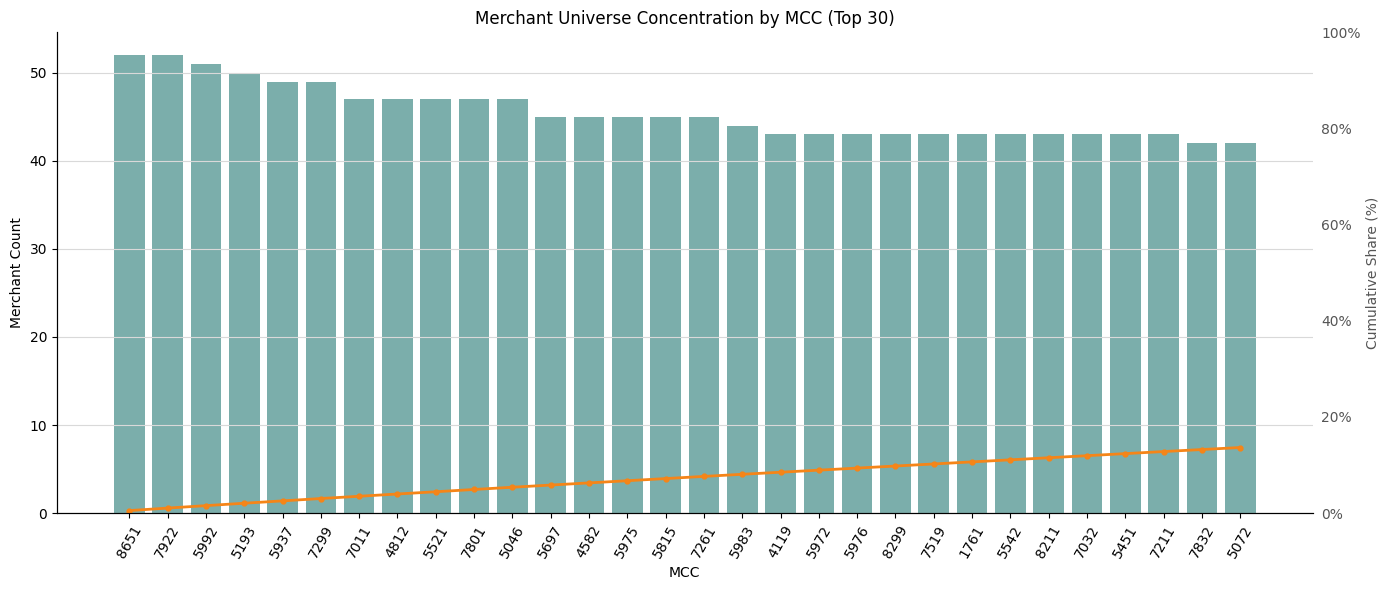

In [13]:
# Focus the chart on the top 30 MCC codes so the labels remain readable.
mcc_plot_df = mcc_concentration_df.head(30).copy()
mcc_plot_df["mcc"] = mcc_plot_df["mcc"].astype(str)

# Create the bar axis first because merchant count is still the primary quantity being displayed.
fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=mcc_plot_df, x="mcc", y="merchant_count", color="#72B7B2", ax=ax1)
ax1.set_title("Merchant Universe Concentration by MCC (Top 30)")
ax1.set_xlabel("MCC")
ax1.set_ylabel("Merchant Count")
ax1.tick_params(axis="x", rotation=60)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax1.grid(axis="x", visible=False)

# Add the cumulative-share line on a secondary axis, but keep that axis visually subordinate.
ax2 = ax1.twinx()
ax2.plot(
    range(len(mcc_plot_df)),
    mcc_plot_df["cumulative_share_pct"],
    color="#F58518",
    marker="o",
    markersize=3.5,
    linewidth=2,
)
ax2.set_ylabel("Cumulative Share (%)", color="#555555")
ax2.set_ylim(0, 100)
ax2.yaxis.set_major_formatter(PercentFormatter(100))
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.tick_params(axis="y", colors="#555555", length=0, pad=6)
ax2.grid(False)

plt.tight_layout()
plt.show()


**Interpretation:** MCC concentration behaves very differently from country concentration. The slower cumulative rise means category exposure is distributed across many merchant classes rather than being dominated by a tiny commercial niche.

**Metrics behind the plot:** `290` distinct MCCs are represented. The top `10` MCCs cover only `4.91%` of merchants, the top `20` `9.36%`, the top `30` `13.64%`, and even the top `100` only `41.23%`. The leading MCC count is `52`, so no single category contributes even `1%` of the merchant universe.

That is a useful structural signal because it tells us the merchant world has two different shapes at once: jurisdiction is top-heavy, but merchant-category mix is broader. For downstream behaviour and fraud analysis, that is healthier than sharp MCC dominance would be, because later layers have room to vary by commercial type instead of inheriting a world overfit to a few categories.

So the important reading is not only that MCC is diffuse. It is that category diversity may partially offset the country skew, which will matter later when we ask whether suspicious pressure is concentrated because of geography, campaign design, or genuine commercial mix.

In [14]:
# First identify the countries with the largest merchant counts.
top_countries = merchant_ids_df["home_country_iso"].value_counts().head(15).index
# Then cross-tab those countries against channel to inspect country-level channel mix.
pd.crosstab(
    merchant_ids_df.loc[merchant_ids_df["home_country_iso"].isin(top_countries), "home_country_iso"],
    merchant_ids_df.loc[merchant_ids_df["home_country_iso"].isin(top_countries), "channel"],
).sort_index()

channel,card_not_present,card_present
home_country_iso,,
AU,53,159
BM,109,327
CH,76,228
DK,50,150
FO,46,139
GH,79,236
IE,84,253
IS,46,139
LU,95,284


Visualise the overall channel split so we can see the merchant seed universe's global CP vs CNP posture at a glance.

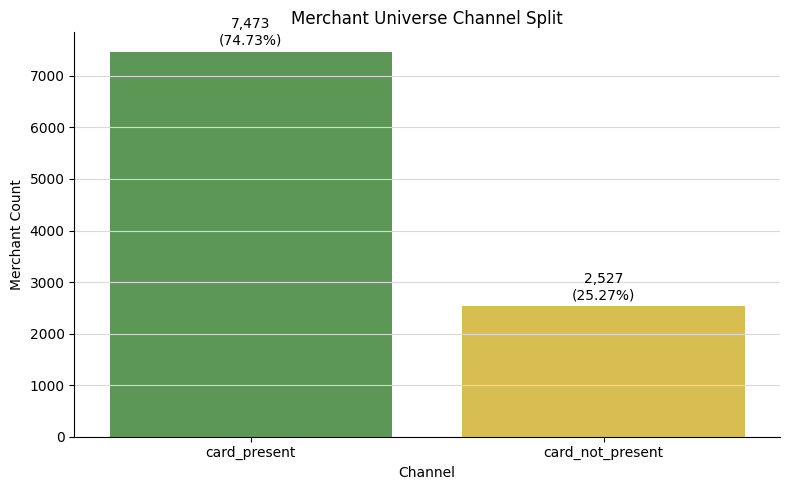

In [15]:
# Rebuild the channel summary with percentage labels so the bar chart can show both counts and share.
channel_plot_df = merchant_ids_df["channel"].value_counts(dropna=False).rename_axis("channel").reset_index(name="merchant_count")
channel_plot_df["merchant_share_pct"] = (channel_plot_df["merchant_count"] / len(merchant_ids_df) * 100).round(2)

# Plot the two channel categories directly because this is a simple composition check rather than a ranked concentration chart.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=channel_plot_df, x="channel", y="merchant_count", hue="channel", dodge=False, palette=["#54A24B", "#EECA3B"], ax=ax)
legend = ax.get_legend()
if legend is not None:
    legend.remove()

ax.set_title("Merchant Universe Channel Split")
ax.set_xlabel("Channel")
ax.set_ylabel("Merchant Count")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.8)
ax.grid(axis="x", visible=False)

# Write count and percentage above each bar so the chart is readable without referring back to the table.
for i, row in channel_plot_df.reset_index(drop=True).iterrows():
    ax.text(i, row["merchant_count"] + 80, f"{row['merchant_count']:,}\n({row['merchant_share_pct']:.2f}%)", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


**Interpretation:** The merchant seed universe is clearly channel-tilted toward `card_present`, not channel-balanced. The `~75 / 25` split tells us the baseline world is anchored in physical or in-person commerce, with `card_not_present` activity present but secondary.

**Metrics behind the plot:** `card_present` accounts for `7,473` merchants (`74.73%`) versus `2,527` `card_not_present` merchants (`25.27%`). With only `2` channel values in the seed universe, this is not noise in a long tail; it is the defining baseline composition.

That matters because channel posture is likely to influence later entity behaviour, device use, fraud opportunity, and case or label composition. A world that begins mostly `card_present` should not later be interpreted as if `card_not_present` pressure is the natural default. Any downstream CNP-heavy fraud or workflow pattern would therefore need to be explained as a campaign overlay, routing effect, or behavioural shift rather than as a neutral starting posture.

So the analytical takeaway is not just the ratio itself. It is the constraint the ratio places on later interpretation: channel comparisons downstream should be read against a deliberately tilted merchant seed, not against an assumption of equal baseline exposure.

#### Question

***Once we know the merchant universe is country-concentrated, do the heavy countries actually behave differently from the rest of the seed world, or are they mostly enlarged versions of the same merchant universe?***

**Why this matters?**

The country Pareto chart tells us where merchant weight sits, but not whether that weight implies specialised merchant composition, different channel behaviour, or a structural analytical risk. This follow-up checks the top-country mix directly.

**Top-country set**
- Investigated countries: `MC, BM, LU, IE, GH, CH, NO, SG, AU, US`
- These are the top 10 home countries by merchant count in the 10,000-row merchant universe.


##### Follow-up plotting angles for the top-country question

The country Pareto view told us **where merchant weight sits**, but it did not tell us whether the heavy countries are merely larger versions of the same merchant universe or whether they also carry a materially different internal shape. To answer that properly we took three angles:

1. **country-level MCC mix comparison** to see whether the heavy countries are broad merchant populations or narrow category pockets
2. **country-level channel mix comparison** to see whether CP/CNP posture is actually country-sensitive or mostly policy-pinned
3. **policy-shaped versus artifact-shaped residual effect** to separate true governed weight from builder-side amplification

The supporting summary tables were prepared in the workspace and saved into `watson_workbench/exports`. The notebook uses those sealed summaries to explain the statistical shape rather than rerunning the scratch investigation from zero.


In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

WORKBENCH = ROOT / "analysis/dev_full_offline_investigation/00_investigation/watson_workbench"
EXPORTS = WORKBENCH / "exports"

MIX_PATH = EXPORTS / "transaction_schema_top_country_mix_summary.csv"
CHANNEL_PATH = EXPORTS / "transaction_schema_top_country_channel_mix.csv"
POLICY_PATH = EXPORTS / "transaction_schema_top_country_policy_artifact_summary.csv"

POLICY_COLOR = "#4C78A8"
ARTIFACT_COLOR = "#E45756"
NEUTRAL = "#7F7F7F"

def draw_mcc_breadth_concentration_plot():
    df = pd.read_csv(MIX_PATH).sort_values("merchant_count", ascending=False).copy()
    global_top10_share_pct = 4.91
    palette = {"policy-shaped": POLICY_COLOR, "artifact-amplified": ARTIFACT_COLOR}

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(
        df["top10_mcc_share_pct"],
        df["distinct_mcc"],
        s=df["merchant_count"] * 0.9,
        c=df["shape_classification"].map(palette),
        alpha=0.85,
        edgecolors="white",
        linewidths=0.9,
    )
    ax.axvline(global_top10_share_pct, color=NEUTRAL, linestyle="--", linewidth=1.5, label="Global top-10 MCC share")
    ax.set_title("Top-Country MCC Breadth vs Concentration")
    ax.set_xlabel("Top 10 MCC Share (%)")
    ax.set_ylabel("Distinct MCCs")
    ax.grid(axis="both", color="#D9D9D9", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    label_offsets = {"US": (0.10, 1.8), "AU": (0.10, -2.2), "SG": (0.10, 1.2), "CH": (0.10, 1.2)}
    for row in df.itertuples(index=False):
        dx, dy = label_offsets.get(row.country_iso, (0.08, 1.5))
        ax.text(row.top10_mcc_share_pct + dx, row.distinct_mcc + dy, row.country_iso, fontsize=9)

    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=POLICY_COLOR, markersize=9, label="Policy-shaped"),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=ARTIFACT_COLOR, markersize=9, label="Artifact-amplified"),
        plt.Line2D([0], [0], color=NEUTRAL, linestyle="--", linewidth=1.5, label="Global top-10 MCC share"),
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
    fig.tight_layout(rect=(0, 0.08, 1, 1))
    plt.show()

def draw_mcc_distance_plot():
    df = pd.read_csv(MIX_PATH).sort_values("mcc_jsd_vs_global_bits", ascending=True).copy()
    palette = {"policy-shaped": POLICY_COLOR, "artifact-amplified": ARTIFACT_COLOR}

    fig, ax = plt.subplots(figsize=(9, 6))
    df_jsd = df.sort_values("mcc_jsd_vs_global_bits", ascending=True)
    ax.barh(
        df_jsd["country_iso"],
        df_jsd["mcc_jsd_vs_global_bits"],
        color=df_jsd["shape_classification"].map(palette),
    )
    ax.set_title("Top-Country Jensen-Shannon Divergence from Global MCC Mix")
    ax.set_xlabel("Jensen-Shannon Divergence (bits, lower = closer to global MCC mix)")
    ax.set_ylabel("")
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for y, row in enumerate(df_jsd.itertuples(index=False)):
        ax.text(row.mcc_jsd_vs_global_bits + 0.004, y - 0.22, f"{row.mcc_jsd_vs_global_bits:.3f}", va="center", fontsize=9)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=POLICY_COLOR, label="Policy-shaped"),
        plt.Rectangle((0, 0), 1, 1, color=ARTIFACT_COLOR, label="Artifact-amplified"),
    ]
    ax.legend(handles=handles, loc="lower right", frameon=True, facecolor="white", edgecolor="#D9D9D9", framealpha=0.95)
    fig.tight_layout()
    plt.show()

def draw_channel_mix_plot():
    df = pd.read_csv(CHANNEL_PATH).sort_values("card_not_present_pct", ascending=True).copy()
    global_cnp_pct = float(df["global_cnp_pct"].iloc[0])
    us_override_min = 25.0
    us_override_max = 40.0

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.axvspan(us_override_min, us_override_max, color="#FDE0A1", alpha=0.45, zorder=0, label="US override band")
    ax.axvline(global_cnp_pct, color=NEUTRAL, linestyle="--", linewidth=1.5, label="Global CNP share")

    colors = [ARTIFACT_COLOR if iso == "US" else POLICY_COLOR for iso in df["country_iso"]]
    ax.barh(df["country_iso"], df["card_not_present_pct"], color=colors)
    ax.set_title("Top-Country Channel Mix")
    ax.set_xlabel("Card-Not-Present Share (%)")
    ax.set_ylabel("")
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(0, max(35, df["card_not_present_pct"].max() + 4))

    for y, row in enumerate(df.itertuples(index=False)):
        ax.text(row.card_not_present_pct + 0.25, y, f"{row.card_not_present_pct:.2f}%", va="center", fontsize=9)

    handles = [
        plt.Line2D([0], [0], color=NEUTRAL, linestyle="--", linewidth=1.5, label="Global CNP share"),
        plt.Rectangle((0, 0), 1, 1, color="#FDE0A1", alpha=0.45, label="US override band"),
        plt.Rectangle((0, 0), 1, 1, color=POLICY_COLOR, label="Policy-pinned countries"),
        plt.Rectangle((0, 0), 1, 1, color=ARTIFACT_COLOR, label="US override active"),
    ]
    ax.legend(handles=handles, loc="lower right", frameon=False)
    fig.tight_layout()
    plt.show()

def draw_policy_artifact_plot():
    df = pd.read_csv(POLICY_PATH).sort_values("builder_vs_standard_delta", ascending=True).copy()
    palette = {"policy-shaped": POLICY_COLOR, "artifact-amplified": ARTIFACT_COLOR}

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [1, 1.2]})

    zoom_df = df.copy()
    ax1.barh(zoom_df["country_iso"], zoom_df["builder_vs_standard_delta"], color=zoom_df["shape_classification"].map(palette))
    ax1.set_title("Residual Effect: Policy-Shaped Countries")
    ax1.set_xlabel("Builder vs Standard Largest-Remainder Delta")
    ax1.set_ylabel("")
    ax1.set_xlim(-2, 2)
    ax1.grid(axis="x", color="#D9D9D9", linewidth=0.8)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)

    full_df = df.copy()
    ax2.barh(full_df["country_iso"], full_df["builder_vs_standard_delta"], color=full_df["shape_classification"].map(palette))
    ax2.set_title("Residual Effect: Full Scale")
    ax2.set_xlabel("Builder vs Standard Largest-Remainder Delta")
    ax2.set_ylabel("")
    ax2.grid(axis="x", color="#D9D9D9", linewidth=0.8)
    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False)

    for y, row in enumerate(full_df.itertuples(index=False)):
        xpos = row.builder_vs_standard_delta + (4 if row.builder_vs_standard_delta >= 0 else -6)
        ha = "left" if row.builder_vs_standard_delta >= 0 else "right"
        ax2.text(xpos, y, f"{int(row.builder_vs_standard_delta)}", va="center", ha=ha, fontsize=9)

    handles = [
        plt.Rectangle((0, 0), 1, 1, color=POLICY_COLOR, label="Policy-shaped"),
        plt.Rectangle((0, 0), 1, 1, color=ARTIFACT_COLOR, label="Artifact-amplified"),
    ]
    fig.legend(handles=handles, loc="lower center", ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    plt.show()


#### Angle 1: country-level MCC mix comparison

Here we are asking whether the heavy countries are simply **large** or whether they are also **merchant-category outliers**. Two different plots are needed because this angle has two separate statistical questions:

- **breadth vs concentration** asks whether a country is broad on MCC coverage or narrow on a small number of dominant categories
- **Jensen-Shannon divergence** asks how far that country's MCC distribution sits from the global MCC distribution across the full merchant universe

If a heavy country were both highly concentrated and far from the global mix, that would suggest a much more specialised merchant world than the country count alone implies.


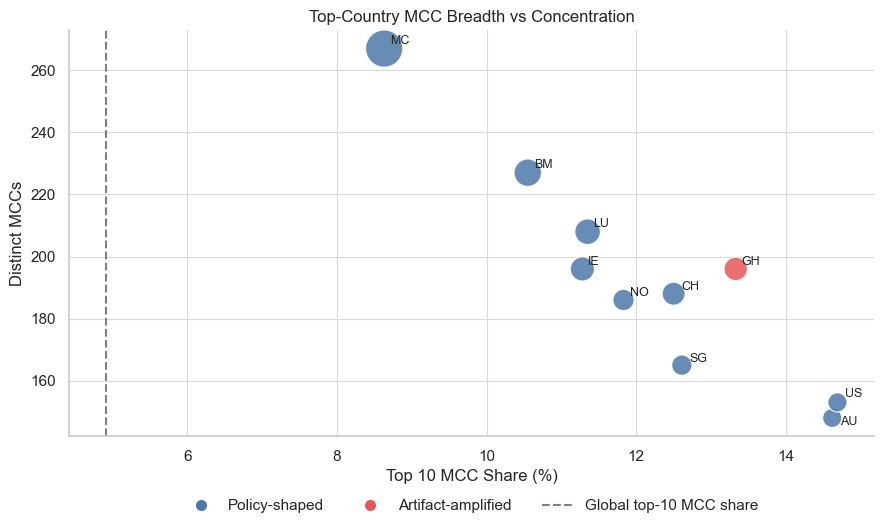

In [17]:
# Angle 1A: breadth versus concentration.
draw_mcc_breadth_concentration_plot()


**Interpretation:** The heavy countries are broad merchant populations, not tiny narrow-category pockets. The full merchant universe carries `290` distinct MCCs, and the global top 10 MCCs account for only `4.91%` of merchants. The heavy-country set remains broad on that same scale: `MC` carries `267` distinct MCCs, `BM` `227`, `LU` `208`, and both `IE` and `GH` `196`. Even where concentration rises, it stays moderate rather than collapsing into a few dominant categories: the top-10-MCC share ranges from `8.63%` in `MC` to `14.69%` in `US`. In context, that means the large countries in the Pareto chart are not large because they each represent one merchant niche; they are large and still structurally broad enough to matter later as genuine merchant populations.


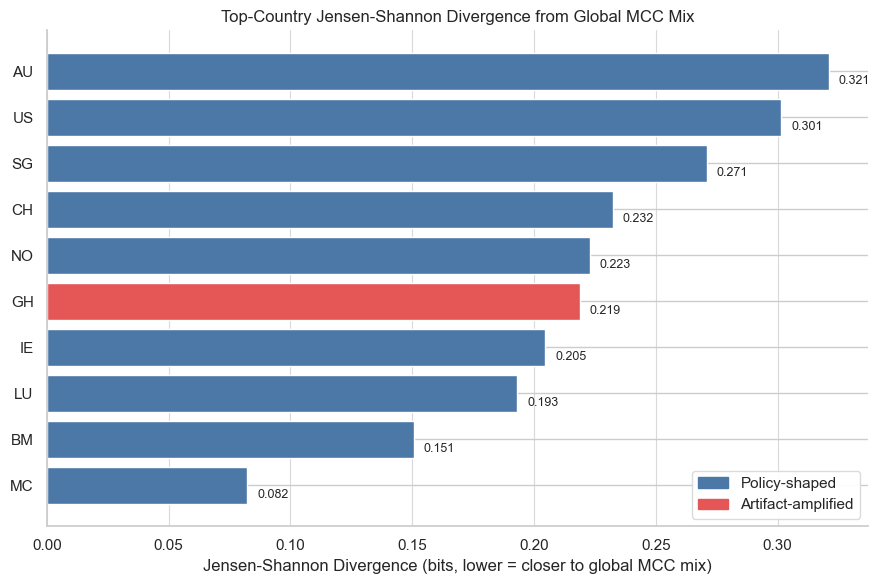

In [18]:
# Angle 1B: distance from the global MCC mix.
draw_mcc_distance_plot()


**Interpretation:** The Jensen-Shannon divergence view says how compositionally different each country's MCC mix is from the global MCC mix. Here the divergence stays **modest rather than explosive**. `MC` is the closest heavy country to the global pattern at `0.0823` bits, followed by `BM` at `0.1508` and `LU` at `0.1932`. The furthest countries in the top set are `AU` at `0.3209` and `US` at `0.3015`, with `GH` at `0.2188`. 

The unit is shown in `bits` because the divergence is calculated with base-2 logarithms; it is an information-distance unit, not a percentage or business KPI. In practice the useful reading is relative: lower values mean closer to the global MCC mix, higher values mean further away. 

The important point is not that higher divergence is automatically bad; it simply means the country is more compositionally distinctive. In this dataset that tells us the heavy countries are not identical copies of the global world, but neither are they radically alien merchant structures. That keeps the country-concentration finding analytically meaningful without forcing us to treat the whole top-country set as unrealistic.

#### Angle 2: country-level channel mix comparison

This angle asks whether country weight also translates into a materially different **CP/CNP posture**, or whether the merchant universe is largely channel-pinned by policy. If the heavy countries had very different channel splits, that would affect how we later interpret traffic, fraud, and operational pressure.


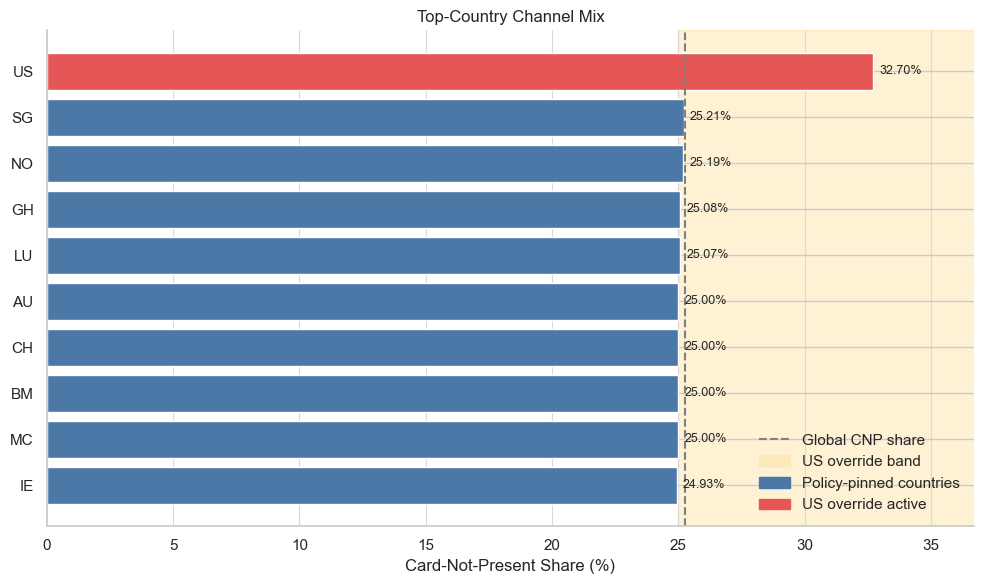

In [19]:
# Angle 2: country-level channel mix comparison.
draw_channel_mix_plot()


**Interpretation:** Country-level channel mix is mostly policy-governed, not strongly country-sensitive. The global channel split is `card_present = 74.73%` and `card_not_present = 25.27%`, and most heavy countries sit almost exactly on that global line: `MC` `75.00 / 25.00`, `BM` `75.00 / 25.00`, `LU` `74.93 / 25.07`, `IE` `75.07 / 24.93`, and `GH` `74.92 / 25.08`. The main exception is `US`, which shifts to `67.30%` `card_present` and `32.70%` `card_not_present`, matching the explicit US override band rather than emergent merchant behaviour. For our context, that means country concentration does **not** automatically imply a different channel universe downstream; most of the top-country set carries the same CP/CNP posture the builder already pinned globally.


#### Angle 3: policy-shaped versus artifact-shaped residual effect

The last angle is about explanation, not just description. Once we know which countries are heavy, we need to know whether that weight is coming from the **governed allocation policy** or from a **builder-side residual effect**. Without this angle, a country can look important for the wrong reason.


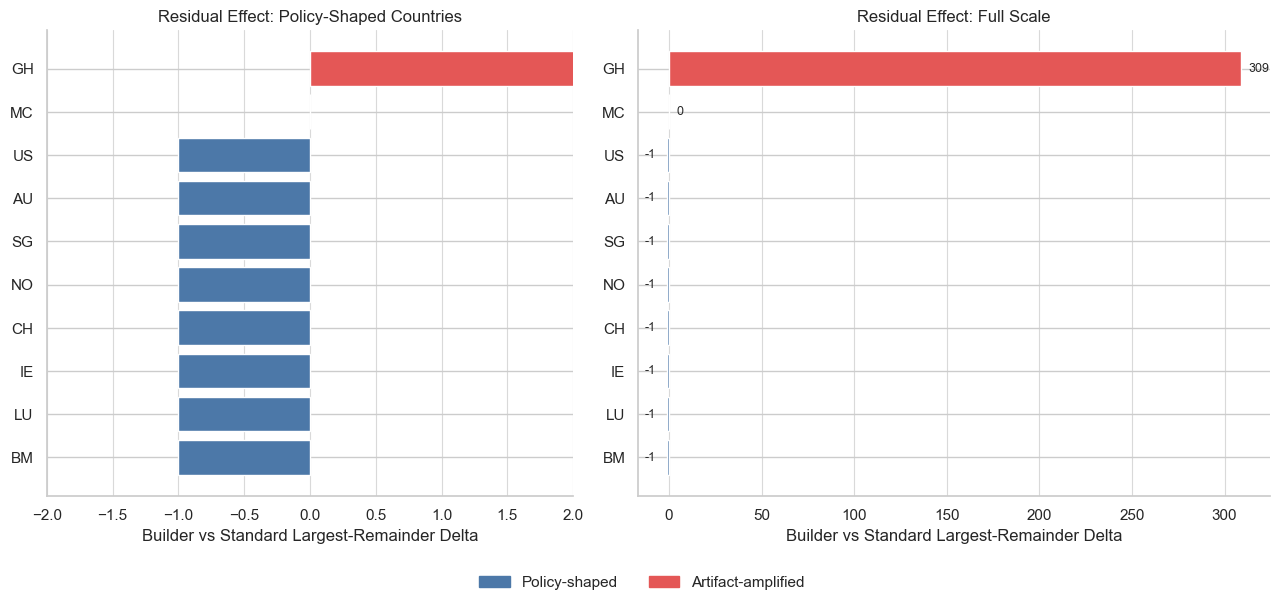

In [20]:
# Angle 3: policy-shaped versus artifact-shaped residual effect.
draw_policy_artifact_plot()


**Interpretation:** This plot is what finally separates governed weight from artifact amplification. Most of the heavy countries are `policy-shaped`: `MC`, `BM`, `LU`, `IE`, `CH`, `NO`, `SG`, `AU`, and `US` differ from the standard largest-remainder counterfactual by only `0` or `-1`, which is immaterial at this scale. `GH` is the clear outlier: it carries a `+309` merchant delta because the builder grants the full leftover block to the first-ranked fractional-remainder country. That means the heavy-country list actually contains two different meanings: genuine policy-weighted countries and one country whose prominence is materially amplified by the reconciliation implementation. In the context of this merchant universe, `GH` therefore needs to be interpreted differently from `MC`, `BM`, or `LU` when we later reason about outlet spread, zone allocation, traffic, fraud, or case/label behaviour.

Notes: GH receiving `+309` merchants is a drift from design as residuals should have been shared amongst the countries with remainders and not just dumped in one country. `To Be Resolved` later

**What This Shows:** These follow-up angles tell us that the heavy-country pattern in the merchant seed is not one single phenomenon. The large countries are broad merchant populations rather than narrow MCC pockets; most of them also sit close to the global channel split, which means country heaviness is not automatically producing a different CP/CNP world. The final residual-allocation view then separates the top-country set into two groups: countries whose prominence is mainly policy-shaped, and `GH`, whose prominence is materially amplified by the builder's residual allocation step. So the top-country question resolves into a more precise answer: most heavy countries are genuinely authored by the governed allocation logic, but one visible outlier is implementation-shaped rather than macro-economically natural.

### A.2: `iso3166_canonical_2024`, `world_bank_gdp_per_capita_20250415`, and `gdp_bucket_map_2024`

Before using these artefacts to explain country concentration, we should inspect them directly as sealed `1A.S0` inputs. At this stage the goal is narrower than interpretation:
- confirm what the datasets actually look like
- confirm the schema we have in hand
- confirm that they cover the merchant-country universe cleanly
- line up merchant-country counts against GDP and bucket values so we can inspect the surface for ourselves before drawing conclusions

So this block stops at **dataset visibility and coverage**. The concentration interpretation comes after that.


In [21]:
iso3166_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_iso   251 non-null    object
 1   alpha3        251 non-null    object
 2   numeric_code  251 non-null    int16 
 3   name          251 non-null    object
 4   region        0 non-null      object
 5   subregion     0 non-null      object
 6   start_date    0 non-null      object
 7   end_date      0 non-null      object
dtypes: int16(1), object(7)
memory usage: 14.3+ KB


In [22]:
gdp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country_iso       190 non-null    object 
 1   observation_year  190 non-null    int64  
 2   gdp_pc_usd_2015   190 non-null    float64
 3   source_series     190 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 6.1+ KB


In [23]:
gdp_bucket_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country_iso   190 non-null    object
 1   bucket_id     190 non-null    int64 
 2   bucket_label  0 non-null      object
 3   method        190 non-null    object
 4   k             190 non-null    int64 
 5   source_year   190 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 9.0+ KB


In [24]:
# Show a few rows from each governed artefact so the raw shape is visible before we summarise anything.
display(iso3166_df.head(10))
display(gdp_df.head(10))
display(gdp_bucket_df.head(10))


,country_iso,alpha3,numeric_code,name,region,subregion,start_date,end_date
0,AD,AND,20,Andorra,None,None,None,None
1,AE,ARE,784,United Arab Emirates,None,None,None,None
2,AF,AFG,4,Afghanistan,None,None,None,None
3,AG,ATG,28,Antigua and Barbuda,None,None,None,None
4,AI,AIA,660,Anguilla,None,None,None,None
5,AL,ALB,8,Albania,None,None,None,None
6,AM,ARM,51,Armenia,None,None,None,None
7,AN,ANT,530,Netherlands Antilles,None,None,None,None
8,AO,AGO,24,Angola,None,None,None,None
9,AQ,ATA,10,Antarctica,None,None,None,None


,country_iso,observation_year,gdp_pc_usd_2015,source_series
0,AD,2024,41034.526672,NY.GDP.PCAP.KD
1,AE,2024,41605.416867,NY.GDP.PCAP.KD
2,AG,2024,18350.185037,NY.GDP.PCAP.KD
3,AL,2024,6549.233874,NY.GDP.PCAP.KD
4,AM,2024,5378.318000,NY.GDP.PCAP.KD
5,AO,2024,2845.477793,NY.GDP.PCAP.KD
6,AR,2024,12774.350660,NY.GDP.PCAP.KD
7,AT,2024,45958.825007,NY.GDP.PCAP.KD
8,AU,2024,61480.670711,NY.GDP.PCAP.KD
9,AW,2024,33373.917459,NY.GDP.PCAP.KD


,country_iso,bucket_id,bucket_label,method,k,source_year
0,AD,3,None,jenks,5,2024
1,AE,3,None,jenks,5,2024
2,AG,2,None,jenks,5,2024
3,AL,1,None,jenks,5,2024
4,AM,1,None,jenks,5,2024
5,AO,1,None,jenks,5,2024
6,AR,1,None,jenks,5,2024
7,AT,3,None,jenks,5,2024
8,AU,3,None,jenks,5,2024
9,AW,2,None,jenks,5,2024


Build a compact profile of the governed artefacts so we can see their landed schema, null exposure, and distinct-count shape.


In [25]:
def column_profile(df: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            'dataset': dataset_name,
            'column': df.columns,
            'dtype': df.dtypes.astype(str).values,
            'null_count': df.isna().sum().values,
            'null_pct': df.isna().mean().mul(100).round(2).values,
            'distinct_count': df.nunique(dropna=False).values,
        }
    )

pd.concat(
    [
        column_profile(iso3166_df, 'iso3166_canonical_2024'),
        column_profile(gdp_df, 'world_bank_gdp_per_capita_20250415'),
        column_profile(gdp_bucket_df, 'gdp_bucket_map_2024'),
    ],
    ignore_index=True,
)


,dataset,column,dtype,null_count,null_pct,distinct_count
0,iso3166_canonical_2024,country_iso,object,0,0.0,251
1,iso3166_canonical_2024,alpha3,object,0,0.0,251
2,iso3166_canonical_2024,numeric_code,int16,0,0.0,251
3,iso3166_canonical_2024,name,object,0,0.0,251
4,iso3166_canonical_2024,region,object,251,100.0,1
5,iso3166_canonical_2024,subregion,object,251,100.0,1
6,iso3166_canonical_2024,start_date,object,251,100.0,1
7,iso3166_canonical_2024,end_date,object,251,100.0,1
8,world_bank_gdp_per_capita_20250415,country_iso,object,0,0.0,190
9,world_bank_gdp_per_capita_20250415,observation_year,int64,0,0.0,1


Capture the first coverage and contract checks for the GDP and bucket artefacts against the merchant-country universe.


In [26]:
merchant_country_set = set(merchant_ids_df['home_country_iso'].dropna().unique())
iso_country_set = set(iso3166_df['country_iso'].dropna().unique())
gdp_country_set = set(gdp_df['country_iso'].dropna().unique())
bucket_country_set = set(gdp_bucket_df['country_iso'].dropna().unique())

pd.DataFrame(
    [
        {'check': 'merchant_country_distinct', 'value': len(merchant_country_set)},
        {'check': 'iso3166_country_distinct', 'value': len(iso_country_set)},
        {'check': 'gdp_country_distinct', 'value': len(gdp_country_set)},
        {'check': 'bucket_country_distinct', 'value': len(bucket_country_set)},
        {'check': 'merchant_countries_missing_from_iso3166', 'value': len(merchant_country_set - iso_country_set)},
        {'check': 'merchant_countries_missing_from_gdp', 'value': len(merchant_country_set - gdp_country_set)},
        {'check': 'merchant_countries_missing_from_bucket_map', 'value': len(merchant_country_set - bucket_country_set)},
        {'check': 'gdp_observation_years', 'value': sorted(gdp_df['observation_year'].dropna().unique().tolist())},
        {'check': 'gdp_source_series', 'value': sorted(gdp_df['source_series'].dropna().unique().tolist())},
        {'check': 'bucket_ids_present', 'value': sorted(gdp_bucket_df['bucket_id'].dropna().unique().tolist())},
        {'check': 'bucket_method', 'value': sorted(gdp_bucket_df['method'].dropna().unique().tolist())},
        {'check': 'bucket_k', 'value': sorted(gdp_bucket_df['k'].dropna().unique().tolist())},
        {'check': 'bucket_source_year', 'value': sorted(gdp_bucket_df['source_year'].dropna().unique().tolist())},
        {'check': 'bucket_label_null_rows', 'value': int(gdp_bucket_df['bucket_label'].isna().sum())},
    ]
)


,check,value
0,merchant_country_distinct,190
1,iso3166_country_distinct,251
2,gdp_country_distinct,190
3,bucket_country_distinct,190
4,merchant_countries_missing_from_iso3166,0
5,merchant_countries_missing_from_gdp,0
6,merchant_countries_missing_from_bucket_map,0
7,gdp_observation_years,[2024]
8,gdp_source_series,[NY.GDP.PCAP.KD]
9,bucket_ids_present,"[1, 2, 3, 4, 5]"


Join merchant-country counts to the GDP and bucket artefacts so we can inspect the aligned surface directly before making any explanatory claim.


In [27]:
merchant_country_gdp_bucket_df = (
    merchant_ids_df.groupby('home_country_iso')
    .size()
    .rename('merchant_count')
    .reset_index()
    .merge(iso3166_df[['country_iso', 'name']], left_on='home_country_iso', right_on='country_iso', how='left')
    .merge(
        gdp_df[['country_iso', 'observation_year', 'gdp_pc_usd_2015', 'source_series']],
        left_on='home_country_iso',
        right_on='country_iso',
        how='left',
        suffixes=('', '_gdp'),
    )
    .merge(
        gdp_bucket_df[['country_iso', 'bucket_id', 'bucket_label', 'method', 'k', 'source_year']],
        left_on='home_country_iso',
        right_on='country_iso',
        how='left',
        suffixes=('', '_bucket'),
    )
    .sort_values(['merchant_count', 'home_country_iso'], ascending=[False, True])
    .reset_index(drop=True)
)
merchant_country_gdp_bucket_df['merchant_share_pct'] = (merchant_country_gdp_bucket_df['merchant_count'] / len(merchant_ids_df) * 100).round(2)
merchant_country_gdp_bucket_df.head(20)[['home_country_iso', 'name', 'merchant_count', 'merchant_share_pct', 'gdp_pc_usd_2015', 'bucket_id', 'bucket_label']]


,home_country_iso,name,merchant_count,merchant_share_pct,gdp_pc_usd_2015,bucket_id,bucket_label
0,MC,Monaco,800,8.00,247170.219911,5,None
1,BM,Bermuda,436,4.36,122117.603587,4,None
2,LU,Luxembourg,379,3.79,104147.173993,4,None
3,IE,Ireland,337,3.37,94474.987971,4,None
4,GH,Ghana,315,3.15,2167.726914,1,None
5,CH,Switzerland,304,3.04,90067.464543,4,None
6,NO,Norway,262,2.62,79667.527231,4,None
7,SG,Singapore,238,2.38,67706.833615,3,None
8,AU,Australia,212,2.12,61480.670711,3,None
9,US,United States,211,2.11,66356.170675,3,None


Finally, inspect the bucket compression itself before turning it into a narrative about country concentration.


In [28]:
bucket_distribution_df = (
    merchant_country_gdp_bucket_df.groupby('bucket_id')
    .agg(
        country_count=('home_country_iso', 'nunique'),
        merchant_count=('merchant_count', 'sum'),
        min_gdp=('gdp_pc_usd_2015', 'min'),
        median_gdp=('gdp_pc_usd_2015', 'median'),
        max_gdp=('gdp_pc_usd_2015', 'max'),
    )
    .reset_index()
    .sort_values('bucket_id')
)
bucket_distribution_df['country_share_pct'] = (bucket_distribution_df['country_count'] / bucket_distribution_df['country_count'].sum() * 100).round(2)
bucket_distribution_df['merchant_share_pct'] = (bucket_distribution_df['merchant_count'] / bucket_distribution_df['merchant_count'].sum() * 100).round(2)
bucket_distribution_df


,bucket_id,country_count,merchant_count,min_gdp,median_gdp,max_gdp,country_share_pct,merchant_share_pct
0,1,122,1517,268.700857,3683.833039,13121.676991,64.21,15.17
1,2,39,2239,14579.400107,21494.685606,37152.563600,20.53,22.39
2,3,23,3726,39683.395349,47960.910576,67706.833615,12.11,37.26
3,4,5,1718,79667.527231,94474.987971,122117.603587,2.63,17.18
4,5,1,800,247170.219911,247170.219911,247170.219911,0.53,8.00


##### GDP and Bucket Relationship Views

These visuals sit on top of the governed GDP and bucket read. The aim here is only to surface the patterns visually before we write any interpretation:
- the full country-level relationship between GDP per capita and merchant count
- how the top merchant countries sit inside the GDP bucket map
- how country share and merchant share compress differently across buckets
- how the low-GDP `GH` exception looks against its bucket-1 peers


In [29]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

GDP_BUCKET_COLORS = {
    1: '#E45756',
    2: '#F58518',
    3: '#72B7B2',
    4: '#54A24B',
    5: '#4C78A8',
}

def style_axes(ax, *, grid_x: bool = False, grid_y: bool = True) -> None:
    # Keep the main plotting frame explicit so the chart does not feel visually detached.
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_color('#444444')
    ax.spines['bottom'].set_color('#444444')
    ax.spines['left'].set_linewidth(1.0)
    ax.spines['bottom'].set_linewidth(1.0)
    ax.tick_params(axis='both', colors='#333333')
    if grid_y:
        ax.grid(axis='y', color='#D9D9D9', linewidth=0.8)
    else:
        ax.grid(axis='y', visible=False)
    if grid_x:
        ax.grid(axis='x', color='#E6E6E6', linewidth=0.8)
    else:
        ax.grid(axis='x', visible=False)


def draw_gdp_relationship_scatter(df: pd.DataFrame) -> None:
    fig, ax = plt.subplots(figsize=(11.5, 7))
    colors = [GDP_BUCKET_COLORS[int(v)] for v in df['bucket_id']]
    ax.scatter(
        df['gdp_pc_usd_2015'],
        df['merchant_count'],
        s=36,
        c=colors,
        alpha=0.82,
        edgecolors='white',
        linewidths=0.5,
    )
    ax.set_xscale('log')
    ax.set_title('Merchant Count vs GDP per Capita by Country')
    ax.set_xlabel('GDP per Capita, constant 2015 USD (log scale)')
    ax.set_ylabel('Merchant Count')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    top_labels = set(df.nlargest(10, 'merchant_count')['home_country_iso'].tolist() + ['GH'])
    for _, row in df[df['home_country_iso'].isin(top_labels)].iterrows():
        ax.text(
            row['gdp_pc_usd_2015'] * 1.03,
            row['merchant_count'] + 7,
            row['home_country_iso'],
            fontsize=9,
            ha='left',
            va='bottom',
        )

    handles = [
        Line2D(
            [0], [0], marker='o', color='w', label=f'Bucket {bucket}',
            markerfacecolor=color, markeredgecolor='white', markersize=8
        )
        for bucket, color in GDP_BUCKET_COLORS.items()
    ]
    legend = ax.legend(handles=handles, title='GDP Bucket', loc='upper left', frameon=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('#BBBBBB')

    rho = df[['merchant_count', 'gdp_pc_usd_2015']].corr(method='spearman').iloc[0, 1]
    ax.text(
        0.985, 0.03, f'Spearman ρ = {rho:.4f}', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=10,
        bbox={'facecolor': 'white', 'edgecolor': '#BBBBBB', 'boxstyle': 'round,pad=0.3'}
    )
    plt.tight_layout()
    plt.show()

def draw_top20_bucket_membership(df: pd.DataFrame) -> None:
    plot_df = df.nlargest(20, 'merchant_count').copy().sort_values('merchant_count', ascending=True)
    fig, ax = plt.subplots(figsize=(10.5, 8))
    bar_colors = [GDP_BUCKET_COLORS[int(v)] for v in plot_df['bucket_id']]
    ax.barh(plot_df['home_country_iso'], plot_df['merchant_count'], color=bar_colors, edgecolor='white')
    ax.set_title('Top 20 Merchant Countries, Colored by GDP Bucket')
    ax.set_xlabel('Merchant Count')
    ax.set_ylabel('Home Country ISO')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for _, row in plot_df.iterrows():
        ax.text(row['merchant_count'] + 8, row['home_country_iso'], f"B{int(row['bucket_id'])}", va='center', ha='left', fontsize=9)

    handles = [
        Line2D([0], [0], marker='s', color='w', label=f'Bucket {bucket}', markerfacecolor=color, markersize=10)
        for bucket, color in GDP_BUCKET_COLORS.items()
    ]
    legend = ax.legend(handles=handles, title='GDP Bucket', loc='lower right', frameon=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('#BBBBBB')
    plt.tight_layout()
    plt.show()

def draw_bucket_compression(df: pd.DataFrame) -> None:
    x = np.arange(len(df))
    width = 0.36
    fig, ax = plt.subplots(figsize=(10, 6.2))
    left = ax.bar(x - width / 2, df['country_share_pct'], width, color='#B8BDC6', label='Country Share', edgecolor='white')
    right = ax.bar(x + width / 2, df['merchant_share_pct'], width, color='#4C78A8', label='Merchant Share', edgecolor='white')
    ax.set_title('GDP Buckets: Country Share vs Merchant Share')
    ax.set_xlabel('GDP Bucket')
    ax.set_ylabel('Share of Total')
    ax.set_xticks(x)
    ax.set_xticklabels([f"Bucket {int(v)}" for v in df['bucket_id']])
    ax.yaxis.set_major_formatter(PercentFormatter(100))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for bars in (left, right):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, height + 0.7, f"{height:.2f}%", ha='center', va='bottom', fontsize=9)

    legend = ax.legend(loc='upper right', frameon=True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('#BBBBBB')
    plt.tight_layout()
    plt.show()

def draw_bucket1_exception(df: pd.DataFrame) -> None:
    plot_df = df[df['bucket_id'] == 1].copy().nlargest(12, 'merchant_count').sort_values('merchant_count', ascending=True)
    fig, ax = plt.subplots(figsize=(10.5, 6.8))
    colors = ['#E45756' if iso == 'GH' else '#B8BDC6' for iso in plot_df['home_country_iso']]
    ax.barh(plot_df['home_country_iso'], plot_df['merchant_count'], color=colors, edgecolor='white')
    ax.set_title('Bucket 1 Peer View: `GH` vs Other Low-GDP Countries')
    ax.set_xlabel('Merchant Count')
    ax.set_ylabel('Home Country ISO')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    for _, row in plot_df.iterrows():
        ax.text(
            row['merchant_count'] + 3,
            row['home_country_iso'],
            f"{int(row['merchant_count'])} | GDP {row['gdp_pc_usd_2015']:,.0f}",
            va='center',
            ha='left',
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


Full country-level GDP vs merchant-count relationship.


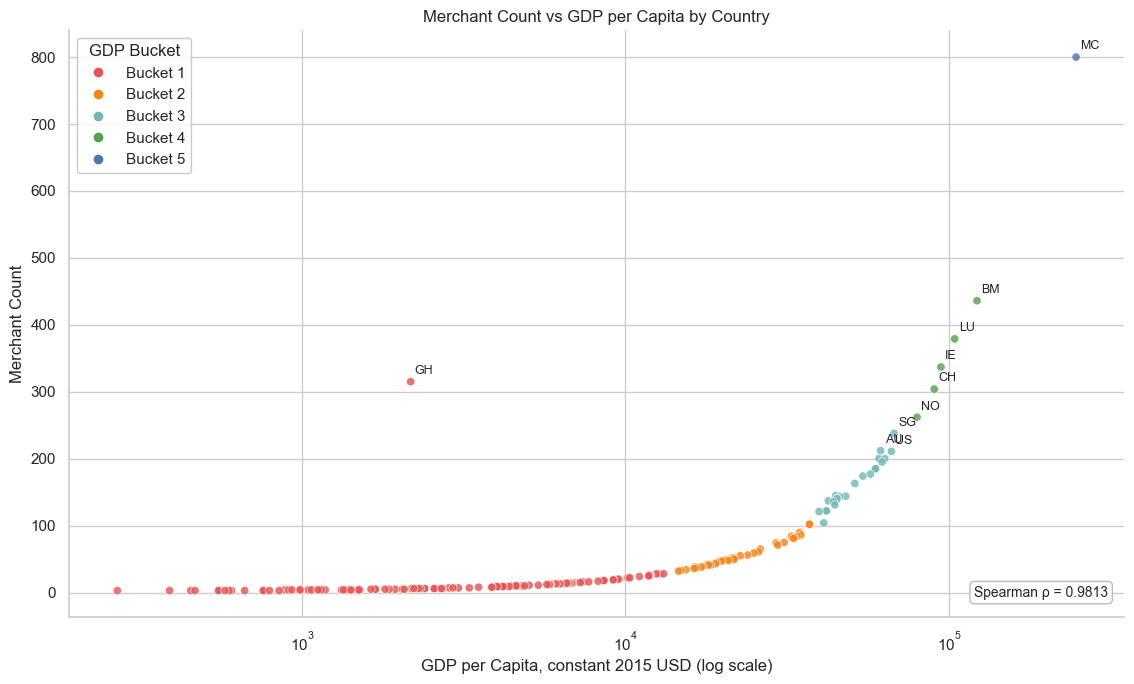

In [30]:
draw_gdp_relationship_scatter(merchant_country_gdp_bucket_df)


**Interpretation:** The scatter shows that the merchant-country ordering is not loosely related to GDP per capita; it is tightly aligned with it. The rank relationship is captured by `Spearman ρ = 0.9813`, which is strong enough that the broad merchant-country ordering should be read as materially GDP-shaped. The upper-right cluster contains the countries we have already seen at the top of the merchant table: `MC` at `800` merchants with GDPpc about `247,170`, `BM` at `436` with `122,118`, `LU` at `379` with `104,147`, `IE` at `337` with `94,475`, and `CH` at `304` with `90,067`. Most of the rest of the points fall into a smooth monotonic curve across the log GDP scale. The visual break is `GH`: it sits far left on the GDP axis at only about `2,168`, but still rises to `315` merchants, which is exactly why it needs to be explained as an exception rather than as part of the normal GDP-shaped pattern.


Top-country merchant concentration, colored by GDP bucket membership.


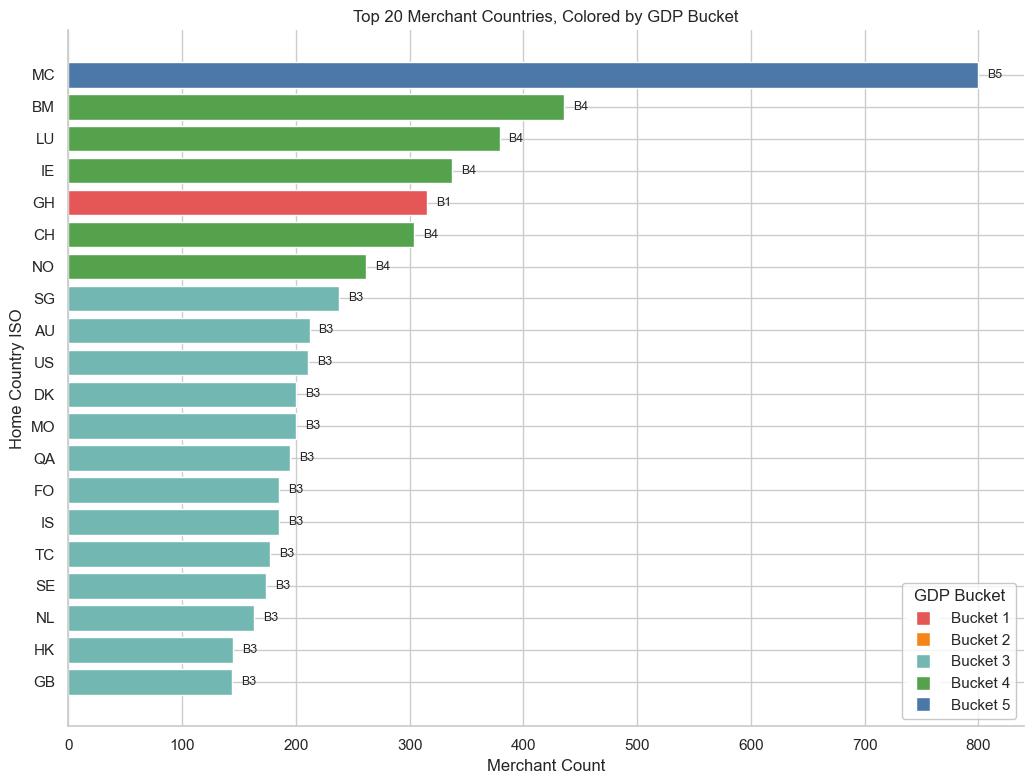

In [31]:
draw_top20_bucket_membership(merchant_country_gdp_bucket_df)


**Interpretation:** The top-country view makes the heavy-country cluster easier to read than the raw table. Of the top `20` merchant countries, `13` are in bucket `3`, `5` are in bucket `4`, `1` is in bucket `5` (`MC`), and only `1` is in bucket `1` (`GH`). There are no bucket-`2` countries in the top `20` at all. In merchant-weight terms, bucket `3` contributes `2,429` merchants (`46.16%` of top-20 merchant weight), bucket `4` contributes `1,718` (`32.65%`), bucket `5` contributes `800` (`15.20%`), and the lone low-bucket exception `GH` contributes `315` (`5.99%`). So the heavy end of the merchant universe is overwhelmingly a bucket `3–5` phenomenon, with `GH` standing apart as the one obvious country that breaks the macro-economic pattern.


Bucket compression: country share versus merchant share.


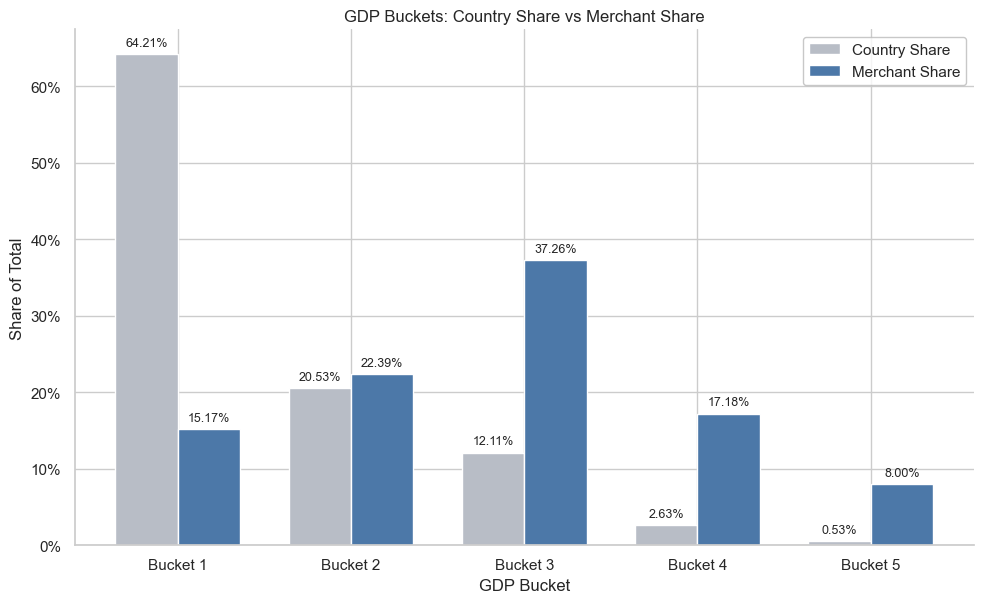

In [32]:
draw_bucket_compression(bucket_distribution_df)


**Interpretation:** This is the bucket-compression story in one view. Bucket `1` contains most of the countries, `122` of `190` (`64.21%`), but only `1,517` merchants (`15.17%`). Buckets `3–5` do the opposite: together they contain only `29` countries (`15.26%` of the country set) but hold `6,244` merchants (`62.44%` of the merchant universe). The upper-rich buckets alone, `4` and `5`, are just `6` countries (`3.16%`) but carry `2,518` merchants (`25.18%`). So the merchant world is not merely broader at low GDP and narrower at high GDP; it is compressed so that a small affluent country set carries a disproportionate amount of merchant weight. That is the structural reason the top-country list feels unusually rich-country-heavy even before we look at specific country names.


The low-GDP exception: `GH` against other bucket-1 peers.


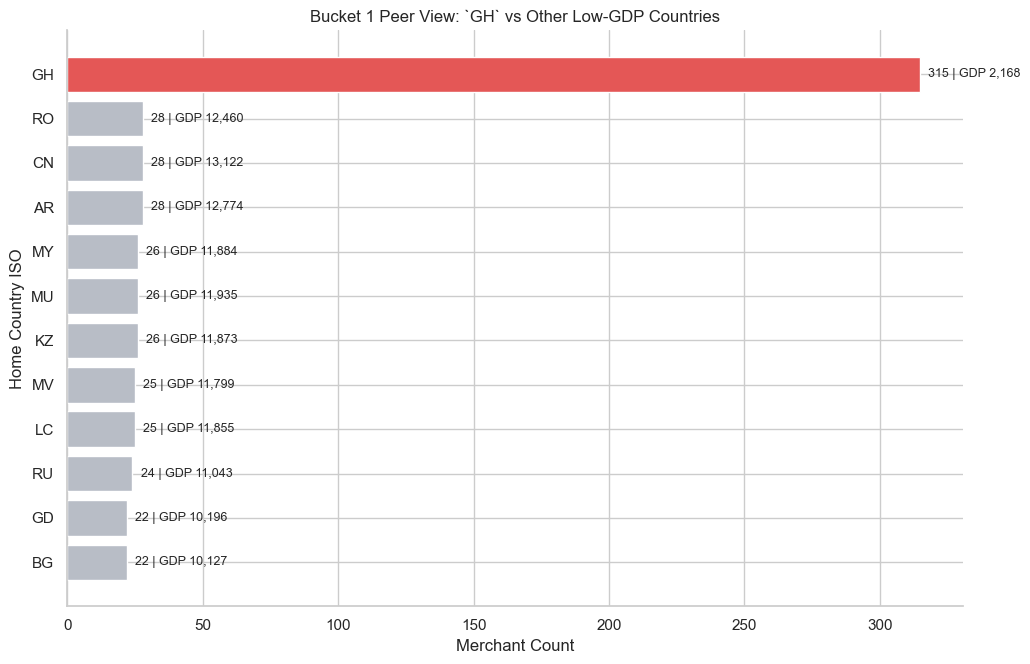

In [33]:
draw_bucket1_exception(merchant_country_gdp_bucket_df)


**Interpretation:** This peer view makes the low-bucket exception concrete rather than abstract. `GH` sits in bucket `1` with GDP per capita of about `2,168`, but it carries `315` merchants (`3.15%` of the full universe). The next-highest bucket-1 peers are `AR`, `CN`, and `RO`, each at only `28` merchants, followed by `KZ`, `MU`, and `MY` at `26`. So `GH` is about `11.25x` larger than the next bucket-1 country by merchant count. In our context, that is the visual reason we do not read `GH` as just another poor-country observation: the GDP artefact places it firmly in the low-income band, but the merchant count behaves like a top-country outlier. That keeps the earlier conclusion intact that `GH` is not explained by the macro-economic surfaces alone and needs the builder-side residual-allocation explanation.


**What This Shows:** Taken together, the GDP and bucket relationship views explain most of the merchant-country concentration we observed earlier. The merchant-country ordering is overwhelmingly GDP-shaped, the top merchant countries are concentrated in buckets `3–5`, and the bucket-compression view shows why a relatively small affluent country set carries such a large share of merchant weight. The only obvious exception is `GH`, which remains a low-bucket top-country outlier. So this block answers the main question directly: the rich-country heaviness in the merchant universe is largely authored by the governed GDP and bucket surfaces, with `GH` standing apart as the main country that still needs builder-side explanation.

##### GDP Surface Compression Views

These visuals are narrower than the earlier GDP relationship section. The goal here is to inspect the frozen bucket map as a compression of the continuous GDP surface itself:
- how the ordered GDP surface is segmented into buckets
- what GDP ranges each bucket actually covers
- how much within-bucket GDP spread is being collapsed into one category

Continuous GDP surface, ordered by GDP rank and coloured by frozen bucket membership.

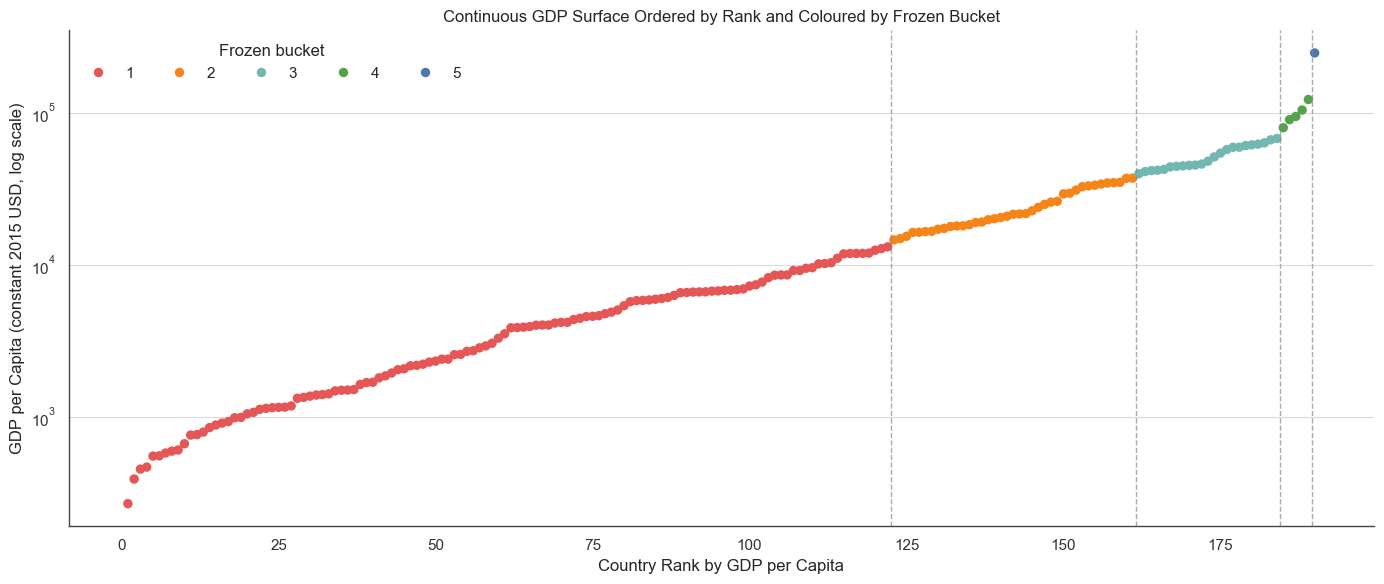

In [34]:
# Reorder countries by GDP per capita so we can look at the continuous macro-economic surface directly.
gdp_ranked_df = merchant_country_gdp_bucket_df.sort_values('gdp_pc_usd_2015').reset_index(drop=True).copy()
gdp_ranked_df['gdp_rank'] = gdp_ranked_df.index + 1

# Draw the ranked GDP surface and colour each point by its frozen bucket assignment.
fig, ax = plt.subplots(figsize=(14, 6))
sns.scatterplot(
    data=gdp_ranked_df,
    x='gdp_rank',
    y='gdp_pc_usd_2015',
    hue='bucket_id',
    palette=GDP_BUCKET_COLORS,
    s=46,
    edgecolor='none',
    ax=ax,
)

# Mark where the frozen bucket transitions happen along the continuous ranked GDP surface.
bucket_boundaries = (
    gdp_ranked_df.groupby('bucket_id')['gdp_rank']
    .agg(['min', 'max'])
    .reset_index()
    .sort_values('bucket_id')
)
for _, row in bucket_boundaries.iloc[:-1].iterrows():
    ax.axvline(row['max'] + 0.5, color='#888888', linestyle='--', linewidth=1, alpha=0.7)

ax.set_title('Continuous GDP Surface Ordered by Rank and Coloured by Frozen Bucket')
ax.set_xlabel('Country Rank by GDP per Capita')
ax.set_ylabel('GDP per Capita (constant 2015 USD, log scale)')
ax.set_yscale('log')
style_axes(ax, grid_x=False, grid_y=True)
ax.legend(title='Frozen bucket', frameon=False, ncol=5, loc='upper left')

plt.tight_layout()
plt.show()


**Interpretation:** This ranked-surface view makes the bucket map legible as a frozen segmentation of the continuous GDP world. The underlying GDP surface is smooth and monotonic on the log scale, while the bucket colours break that surface into discrete macro-economic bands. The dashed vertical lines show where the frozen bucket boundaries land in rank space, and the result is informative: the lower-income end is long and dense, while the upper-income end is short and compressed into a small number of countries. That means the bucket map is not arbitrarily chopping the GDP surface into equal-sized groups; it is compressing a very uneven macro-economic world into a small ordered category system. In practical terms, this is why the later merchant-allocation logic can inherit a strong rich-country shape even though the raw GDP surface itself is continuous rather than categorical.

GDP distribution within each frozen bucket.

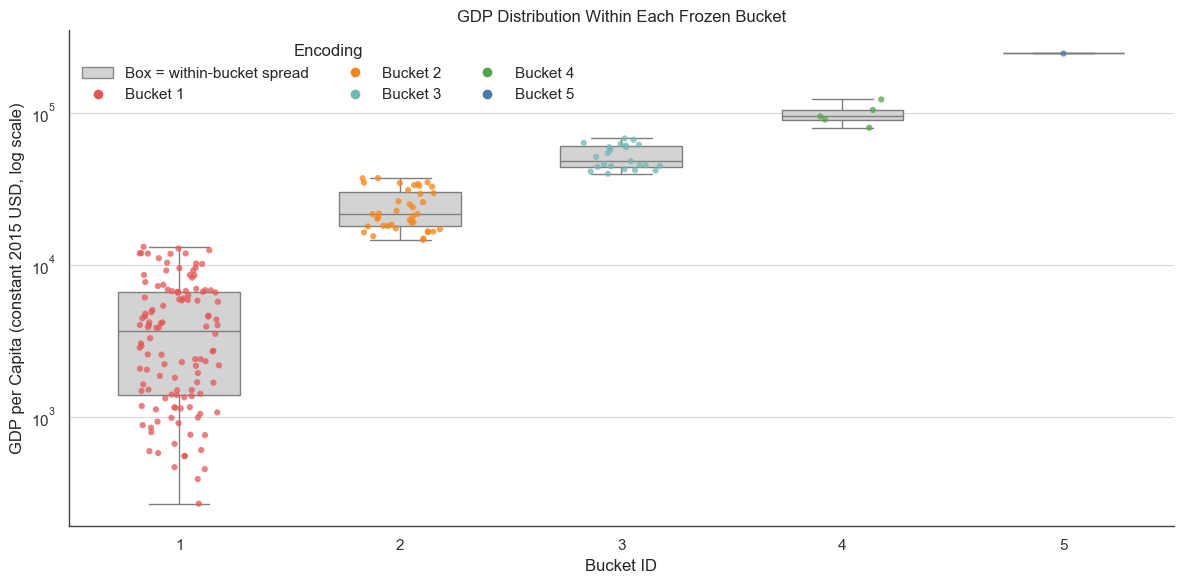

In [35]:
# Keep bucket id categorical here so each frozen bucket gets its own distribution panel on the x-axis.
gdp_bucket_distribution_df = merchant_country_gdp_bucket_df.copy()
gdp_bucket_distribution_df['bucket_id'] = gdp_bucket_distribution_df['bucket_id'].astype(int).astype(str)
bucket_order = ['1', '2', '3', '4', '5']
gdp_bucket_distribution_df['bucket_id'] = pd.Categorical(gdp_bucket_distribution_df['bucket_id'], categories=bucket_order, ordered=True)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    data=gdp_bucket_distribution_df,
    x='bucket_id',
    y='gdp_pc_usd_2015',
    order=bucket_order,
    color='#D3D3D3',
    width=0.55,
    fliersize=0,
    ax=ax,
)
sns.stripplot(
    data=gdp_bucket_distribution_df,
    x='bucket_id',
    y='gdp_pc_usd_2015',
    hue='bucket_id',
    order=bucket_order,
    hue_order=bucket_order,
    palette={str(k): v for k, v in GDP_BUCKET_COLORS.items()},
    jitter=0.18,
    size=4.5,
    alpha=0.75,
    dodge=False,
    ax=ax,
)

ax.set_title('GDP Distribution Within Each Frozen Bucket')
ax.set_xlabel('Bucket ID')
ax.set_ylabel('GDP per Capita (constant 2015 USD, log scale)')
ax.set_yscale('log')
style_axes(ax, grid_x=False, grid_y=True)

legend_handles = [Patch(facecolor='#D3D3D3', edgecolor='#888888', label='Box = within-bucket spread')]
legend_handles.extend(
    Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=f'Bucket {bucket_id}')
    for bucket_id, color in GDP_BUCKET_COLORS.items()
)
ax.legend(handles=legend_handles, title='Encoding', frameon=False, loc='upper left', ncol=3)

plt.tight_layout()
plt.show()


**Interpretation:** This within-bucket distribution view shows what the frozen compression is actually collapsing. Bucket `1` is not just the lowest bucket; it is a very wide low-income band with substantial internal spread, stretching from about `269` to `13,122` GDP per capita and containing `122` countries. Bucket `2` then narrows into a mid-income band of about `14,579` to `37,153`, bucket `3` into an affluent band of about `39,683` to `67,707`, and bucket `4` into a still tighter upper-rich band of about `79,668` to `122,118`. Bucket `5` is a singleton extreme represented only by `MC` at about `247,170`.

So the bucket map does not preserve the same level of resolution across the GDP surface. It keeps the upper end narrow and sharply differentiated, while the lower end is grouped into a much broader internal band. That matters because later policy logic operating on buckets is inheriting this asymmetry: low-income countries are treated in a much more compressed way than high-income ones.

GDP range compression by frozen bucket.

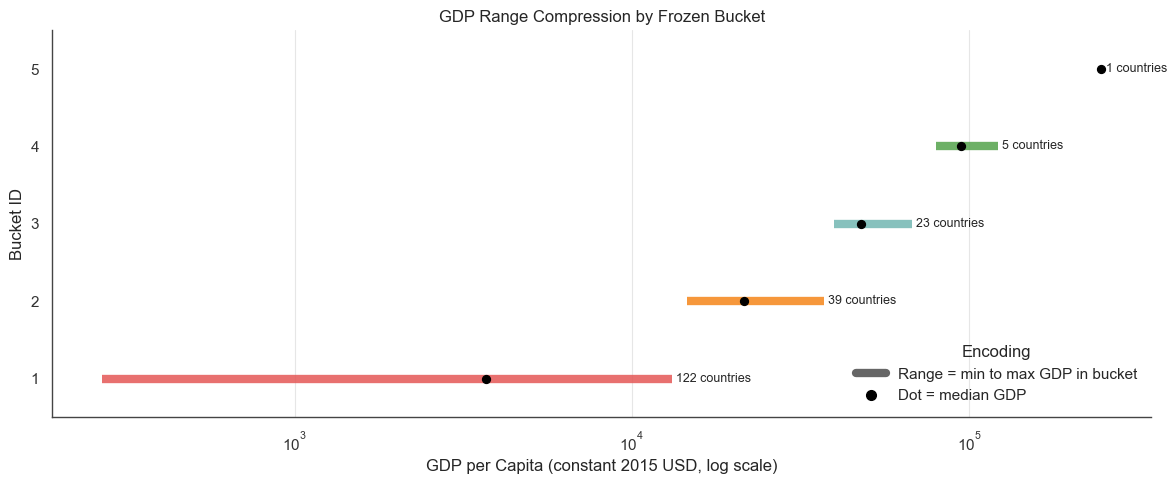

In [36]:
# Collapse each bucket to its minimum, median, and maximum GDP so the compression ranges are explicit.
gdp_bucket_range_df = (
    merchant_country_gdp_bucket_df.groupby('bucket_id')
    .agg(
        min_gdp=('gdp_pc_usd_2015', 'min'),
        median_gdp=('gdp_pc_usd_2015', 'median'),
        max_gdp=('gdp_pc_usd_2015', 'max'),
        country_count=('home_country_iso', 'nunique'),
    )
    .reset_index()
    .sort_values('bucket_id')
)

fig, ax = plt.subplots(figsize=(12, 5))
for _, row in gdp_bucket_range_df.iterrows():
    y = int(row['bucket_id'])
    color = GDP_BUCKET_COLORS[y]
    ax.hlines(y=y, xmin=row['min_gdp'], xmax=row['max_gdp'], color=color, linewidth=6, alpha=0.85)
    ax.scatter(row['median_gdp'], y, color='black', s=32, zorder=3)
    ax.text(row['max_gdp'] * 1.03, y, f"{int(row['country_count'])} countries", va='center', fontsize=9)

range_handle = Line2D([0], [0], color='#666666', linewidth=6, label='Range = min to max GDP in bucket')
median_handle = Line2D([0], [0], marker='o', color='black', linewidth=0, markersize=7, label='Dot = median GDP')

ax.set_title('GDP Range Compression by Frozen Bucket')
ax.set_xlabel('GDP per Capita (constant 2015 USD, log scale)')
ax.set_ylabel('Bucket ID')
ax.set_xscale('log')
ax.set_yticks(gdp_bucket_range_df['bucket_id'].tolist())
ax.set_ylim(0.5, gdp_bucket_range_df['bucket_id'].max() + 0.5)
style_axes(ax, grid_x=True, grid_y=False)
ax.legend(handles=[range_handle, median_handle], title='Encoding', frameon=False, loc='lower right')

plt.tight_layout()
plt.show()


**Interpretation:** This range-compression chart makes the frozen discretisation explicit. Each horizontal band is the full GDP span that gets collapsed into one bucket, and the black dot marks the median of that band. The key reality is asymmetry: bucket `1` covers roughly `269` to `13,122` and carries `122` countries, bucket `2` spans roughly `14,579` to `37,153` with `39` countries, bucket `3` spans roughly `39,683` to `67,707` with `23` countries, bucket `4` spans roughly `79,668` to `122,118` with `5` countries, and bucket `5` isolates a single ultra-high-GDP country at about `247,170`.

So the compression is not uniform. It is deliberately coarse at the low end and increasingly fine toward the top. In the context of the merchant builder, that means upper-income countries retain more macro-economic distinction while much of the lower-income world is grouped into broader common treatment bands.

**What This Shows:** The point of this subsection was to inspect the frozen bucket map not just as a label table, but as a compression of the continuous GDP surface that `1A.S0` receives. Taken together, the three views show that the compression is real, ordered, and asymmetric. The GDP surface itself is smooth, but the bucket map collapses it into coarse low-income treatment bands and increasingly fine upper-income bands. That means the bucket map preserves more macro-economic distinction at the rich end than at the poor end. In practical terms, later policy and allocation logic are not reading a neutral categorical surface; they are reading a frozen compression that already privileges upper-end separation while grouping much of the lower-income world into broader common bands.

### A.3: `merchant_allocation.1A.yaml` Against `transaction_schema_merchant_ids`

We now shift from the GDP and bucket artefacts to the merchant-allocation policy that helped author the merchant universe before `1A.S0` ingested it.

The questions in this block are:
- what part of the merchant-country world is already explained by GDP alone
- what changes when the regional multipliers are added
- what changes when the full intended policy is applied
- where the implemented builder diverges from the intended policy path


Policy setup and four-world construction.


In [37]:
import json
import math

# Keep the current merchant snapshot manifest close because it records the exact allocation policy used to author the parquet.
transaction_schema_manifest_path = ROOT / "reference" / "layer1" / "transaction_schema_merchant_ids" / "2026-01-03" / "transaction_schema_merchant_ids.manifest.json"
transaction_schema_manifest = json.loads(transaction_schema_manifest_path.read_text(encoding="utf-8"))
merchant_allocation_policy = transaction_schema_manifest["allocation_policy"]

# Capture the active policy knobs in one table before we compare worlds.
merchant_allocation_policy_summary_df = pd.DataFrame([
    {"parameter": "policy_version", "value": merchant_allocation_policy["policy_version"]},
    {"parameter": "total_merchants", "value": merchant_allocation_policy["total_merchants"]},
    {"parameter": "min_per_iso", "value": merchant_allocation_policy["min_per_iso"]},
    {"parameter": "max_per_iso", "value": merchant_allocation_policy["max_per_iso"]},
    {"parameter": "base_metric", "value": merchant_allocation_policy["weighting"]["base_metric"]},
    {"parameter": "exponent", "value": merchant_allocation_policy["weighting"]["exponent"]},
    {"parameter": "heavy_tail", "value": merchant_allocation_policy["weighting"]["heavy_tail"]},
    {"parameter": "EU_multiplier", "value": merchant_allocation_policy["regional_adjustments"]["EU"]["multiplier"]},
    {"parameter": "APAC_multiplier", "value": merchant_allocation_policy["regional_adjustments"]["APAC"]["multiplier"]},
])
merchant_allocation_policy_summary_df

# Re-implement the policy logic in notebook form so we can inspect intended worlds separately from the current builder artifact.
def compute_allocation_weights(gdp_country_df: pd.DataFrame, allocation_policy: dict) -> dict[str, float]:
    exponent = float(allocation_policy["weighting"]["exponent"])
    weights = {row.iso: max(float(row.gdp_pc_usd_2015), 0.0) ** exponent for row in gdp_country_df.itertuples(index=False)}

    total = sum(weights.values())
    if total <= 0:
        raise ValueError("GDP weights sum to zero")
    weights = {iso: weight / total for iso, weight in weights.items()}

    # Apply the regional multiplier layer when it is present in the policy.
    for cfg in (allocation_policy.get("regional_adjustments", {}) or {}).values():
        iso_codes = cfg.get("iso_codes", [])
        multiplier = float(cfg.get("multiplier", 1.0))
        if multiplier == 1.0:
            continue
        for iso in iso_codes:
            if iso in weights:
                weights[iso] *= multiplier
        total = sum(weights.values())
        weights = {iso: weight / total for iso, weight in weights.items()}

    # Apply the heavy-tail step to the strongest countries when enabled.
    heavy_tail = float(allocation_policy["weighting"].get("heavy_tail", 0.0))
    if heavy_tail > 0:
        iso_sorted = sorted(weights.items(), key=lambda kv: kv[1], reverse=True)
        top_n = max(1, int(len(iso_sorted) * heavy_tail))
        boost = 1.0 + heavy_tail
        for iso, _ in iso_sorted[:top_n]:
            weights[iso] *= boost
        total = sum(weights.values())
        weights = {iso: weight / total for iso, weight in weights.items()}

    return weights

def corrected_allocate(weights: dict[str, float], allocation_policy: dict) -> dict[str, int]:
    total_merchants = int(allocation_policy["total_merchants"])
    min_per_iso = int(allocation_policy["min_per_iso"])
    max_per_iso = int(allocation_policy["max_per_iso"])

    iso_list = sorted(weights.keys())
    counts = {iso: min_per_iso for iso in iso_list}
    remaining = total_merchants - min_per_iso * len(iso_list)
    capacity = {iso: max(0, max_per_iso - counts[iso]) for iso in iso_list}
    usable_weights = {iso: weights[iso] if capacity[iso] > 0 else 0.0 for iso in iso_list}
    total_weight = sum(usable_weights.values())
    raw_extra = {iso: (usable_weights[iso] / total_weight) * remaining for iso in iso_list}
    extra = {iso: min(capacity[iso], math.floor(raw_extra[iso])) for iso in iso_list}
    leftover = remaining - sum(extra.values())

    # Distribute the remainder one country at a time by ranked fractional remainder.
    if leftover > 0:
        fractional = {
            iso: (raw_extra[iso] - math.floor(raw_extra[iso])) if capacity[iso] > extra[iso] else -1.0
            for iso in iso_list
        }
        eligible = [iso for iso in iso_list if capacity[iso] > extra[iso]]
        eligible.sort(key=lambda iso: (-fractional[iso], iso))
        for iso in eligible[:leftover]:
            extra[iso] += 1

    for iso in iso_list:
        counts[iso] += extra[iso]
    return counts

def implemented_allocate(weights: dict[str, float], allocation_policy: dict) -> dict[str, int]:
    total_merchants = int(allocation_policy["total_merchants"])
    min_per_iso = int(allocation_policy["min_per_iso"])
    max_per_iso = int(allocation_policy["max_per_iso"])

    iso_list = sorted(weights.keys())
    counts = {iso: min_per_iso for iso in iso_list}
    remaining = total_merchants - min_per_iso * len(iso_list)
    capacity = {iso: max(0, max_per_iso - counts[iso]) for iso in iso_list}
    usable_weights = {iso: weights[iso] if capacity[iso] > 0 else 0.0 for iso in iso_list}
    total_weight = sum(usable_weights.values())
    raw_extra = {iso: (usable_weights[iso] / total_weight) * remaining for iso in iso_list}
    extra = {iso: min(capacity[iso], math.floor(raw_extra[iso])) for iso in iso_list}
    leftover = remaining - sum(extra.values())

    # Mirror the builder path currently implemented in the reference authoring script.
    if leftover > 0:
        fractional = {
            iso: (raw_extra[iso] - math.floor(raw_extra[iso])) if capacity[iso] > extra[iso] else 0.0
            for iso in iso_list
        }
        eligible = [iso for iso in iso_list if capacity[iso] > extra[iso]]
        eligible.sort(key=lambda iso: (-fractional[iso], iso))
        for iso in eligible:
            if leftover <= 0:
                break
            counts_available = capacity[iso] - extra[iso]
            grant = min(counts_available, leftover)
            extra[iso] += grant
            leftover -= grant

    for iso in iso_list:
        counts[iso] += extra[iso]
    return counts

# Build the country-level GDP surface once, because all four worlds share the same GDP and ISO support base.
policy_country_base_df = merchant_country_gdp_bucket_df[["home_country_iso", "gdp_pc_usd_2015", "merchant_count"]].copy()
policy_country_base_df = policy_country_base_df.rename(columns={"home_country_iso": "iso", "merchant_count": "observed_count"})

# World 1: GDP-only corrected allocation.
gdp_only_policy = json.loads(json.dumps(merchant_allocation_policy))
gdp_only_policy["regional_adjustments"] = {}
gdp_only_policy["weighting"]["heavy_tail"] = 0.0
gdp_only_weights = compute_allocation_weights(policy_country_base_df[["iso", "gdp_pc_usd_2015"]], gdp_only_policy)
gdp_only_counts = corrected_allocate(gdp_only_weights, gdp_only_policy)

# World 2: GDP plus regional multipliers, still before the heavy-tail step.
gdp_region_policy = json.loads(json.dumps(merchant_allocation_policy))
gdp_region_policy["weighting"]["heavy_tail"] = 0.0
gdp_region_weights = compute_allocation_weights(policy_country_base_df[["iso", "gdp_pc_usd_2015"]], gdp_region_policy)
gdp_region_counts = corrected_allocate(gdp_region_weights, gdp_region_policy)

# World 3: the intended full policy path under corrected remainder reconciliation.
final_policy_weights = compute_allocation_weights(policy_country_base_df[["iso", "gdp_pc_usd_2015"]], merchant_allocation_policy)
corrected_final_counts = corrected_allocate(final_policy_weights, merchant_allocation_policy)

# World 4: the current implemented builder path.
implemented_final_counts = implemented_allocate(final_policy_weights, merchant_allocation_policy)

# Combine the four worlds back onto the observed merchant-country surface so every plot reads from one table.
merchant_allocation_worlds_df = policy_country_base_df.copy()
merchant_allocation_worlds_df["gdp_only_count"] = merchant_allocation_worlds_df["iso"].map(gdp_only_counts)
merchant_allocation_worlds_df["gdp_region_count"] = merchant_allocation_worlds_df["iso"].map(gdp_region_counts)
merchant_allocation_worlds_df["corrected_final_count"] = merchant_allocation_worlds_df["iso"].map(corrected_final_counts)
merchant_allocation_worlds_df["implemented_final_count"] = merchant_allocation_worlds_df["iso"].map(implemented_final_counts)

# Make the policy-step deltas explicit so later plots can show how each layer moves the country counts.
merchant_allocation_worlds_df["regional_uplift"] = merchant_allocation_worlds_df["gdp_region_count"] - merchant_allocation_worlds_df["gdp_only_count"]
merchant_allocation_worlds_df["heavytail_uplift"] = merchant_allocation_worlds_df["corrected_final_count"] - merchant_allocation_worlds_df["gdp_region_count"]
merchant_allocation_worlds_df["implementation_artifact"] = merchant_allocation_worlds_df["implemented_final_count"] - merchant_allocation_worlds_df["corrected_final_count"]

merchant_allocation_worlds_df.sort_values("observed_count", ascending=False).head(15)


,iso,gdp_pc_usd_2015,observed_count,gdp_only_count,gdp_region_count,corrected_final_count,implemented_final_count,regional_uplift,heavytail_uplift,implementation_artifact
0,MC,247170.219911,800,800,800,800,800,0,0,0
1,BM,122117.603587,436,426,417,437,436,-9,20,-1
2,LU,104147.173993,379,353,362,380,379,9,18,-1
3,IE,94474.987971,337,314,322,338,337,8,16,-1
4,GH,2167.726914,315,7,7,6,315,0,-1,309
5,CH,90067.464543,304,297,290,305,304,-7,15,-1
6,NO,79667.527231,262,257,251,263,262,-6,12,-1
7,SG,67706.833615,238,212,227,239,238,15,12,-1
8,AU,61480.670711,212,189,203,213,212,14,10,-1
9,US,66356.170675,211,207,202,212,211,-5,10,-1


**Ranked Surface**

Start with the full merchant-country count surface before zooming into the top end.


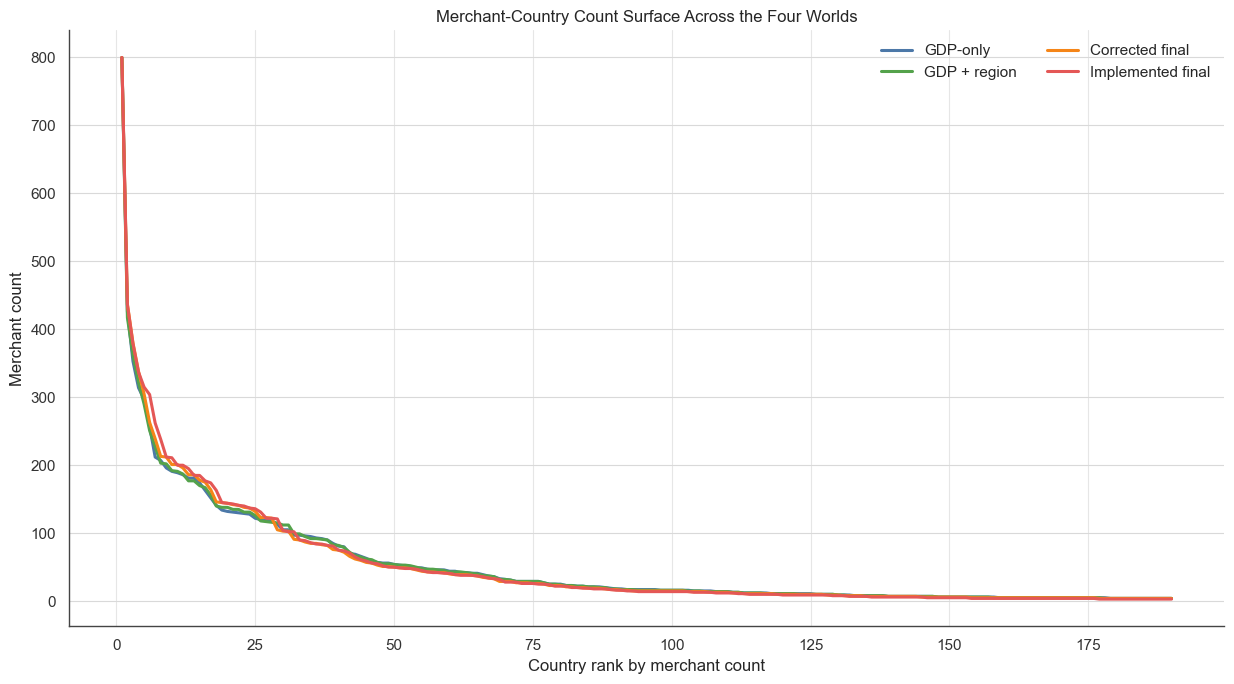

In [38]:
WORLD_COLORS = {
    "GDP-only": "#4C78A8",
    "GDP + region": "#54A24B",
    "Corrected final": "#F58518",
    "Implemented final": "#E45756",
}
EFFECT_COLORS = {
    "Regional uplift": "#54A24B",
    "Heavy-tail uplift": "#F58518",
    "Implementation artifact": "#E45756",
}

world_columns = [
    ("GDP-only", "gdp_only_count"),
    ("GDP + region", "gdp_region_count"),
    ("Corrected final", "corrected_final_count"),
    ("Implemented final", "implemented_final_count"),
]

fig, ax = plt.subplots(figsize=(12.5, 7))
for label, col in world_columns:
    ranked_counts = merchant_allocation_worlds_df[col].sort_values(ascending=False).to_list()
    ranks = np.arange(1, len(ranked_counts) + 1)
    ax.plot(ranks, ranked_counts, linewidth=2.2, color=WORLD_COLORS[label], label=label)

ax.set_title("Merchant-Country Count Surface Across the Four Worlds")
ax.set_xlabel("Country rank by merchant count")
ax.set_ylabel("Merchant count")
style_axes(ax, grid_x=True, grid_y=True)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


This ranked-surface view answers the broadest version of the question first: how different are these four merchant-country worlds overall? The answer is that they are mostly the same in global shape, with one decisive rupture. GDP-only, GDP + region, and the corrected final policy all trace a very similar steep top-heavy curve, which tells us that the merchant-country world is already strongly concentrated before we even reach the builder's current implemented path. In other words, the basic concentration story is not an accident of one bad line of code; it is authored by the policy itself.

What then changes as we move across the worlds is not the existence of concentration, but its refinement. The regional step slightly lifts selected bloc countries, the corrected final policy concentrates the top end further, and the implemented final path largely sits on top of that same surface except for one visible discontinuity near the early ranks. That discontinuity is the clue that there is an implementation artifact layered on top of an otherwise coherent policy-authored world. So this chart gives us the macro reading: the merchant universe is fundamentally policy-shaped, but not perfectly so at the implemented edge.


**Top-End Zoom**

Now narrow the view to the top 30 ranks so the early-country separation becomes visible.


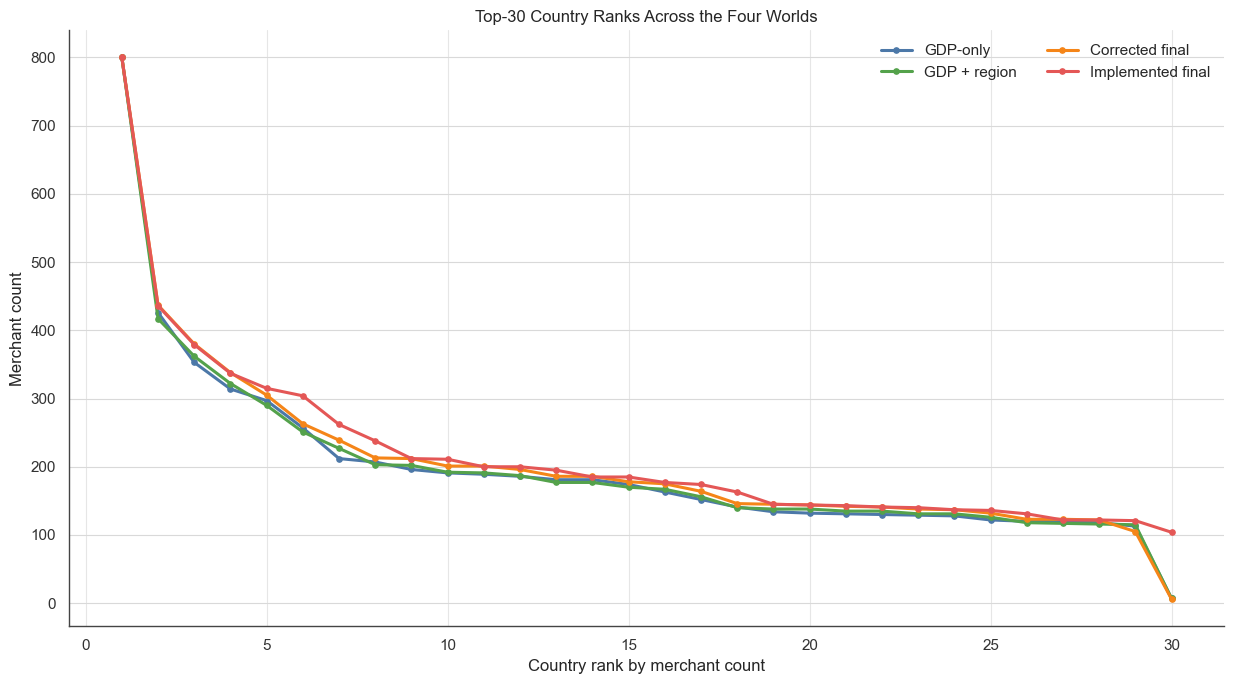

In [39]:
# Zoom into the top end because the full ranked curve compresses the early-rank differences too heavily.
merchant_allocation_top30_rank_df = merchant_allocation_worlds_df.sort_values("observed_count", ascending=False).head(30).copy()

fig, ax = plt.subplots(figsize=(12.5, 7))
for label, col in world_columns:
    ranked_counts = merchant_allocation_top30_rank_df[col].sort_values(ascending=False).to_list()
    ranks = np.arange(1, len(ranked_counts) + 1)
    ax.plot(ranks, ranked_counts, marker="o", markersize=3.8, linewidth=2.2, color=WORLD_COLORS[label], label=label)

ax.set_title("Top-30 Country Ranks Across the Four Worlds")
ax.set_xlabel("Country rank by merchant count")
ax.set_ylabel("Merchant count")
style_axes(ax, grid_x=True, grid_y=True)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()


This zoomed top-end view makes the refinement story visible in a way the full ranked curve cannot. At the highest ranks, the four worlds are no longer visually collapsed onto one another. `MC` remains fixed across all worlds, which tells us its dominance is already locked in by the base weighted allocation and the cap. Below that, the worlds separate in a structured way: the GDP-only world sits lowest for several leading countries, the regional step lifts selected bloc countries, the corrected final policy pushes the top end further upward, and the implemented final path mostly tracks that corrected surface. That means the top-country world is not being created in one jump; it is being progressively authored in stages.

The other important thing this plot exposes is where the implemented world stops behaving like a smooth refinement of the corrected final world. Around the early ranks, one country breaks away from the otherwise close clustering. So this chart adds a new finding beyond the original ranked surface: the top-country hierarchy is not only concentrated, it is staged, and the implemented path carries one early-rank deviation that is too large to treat as normal policy refinement.


**Rank Differences**

Translate the four worlds into incremental changes by rank so each policy layer can be read directly.


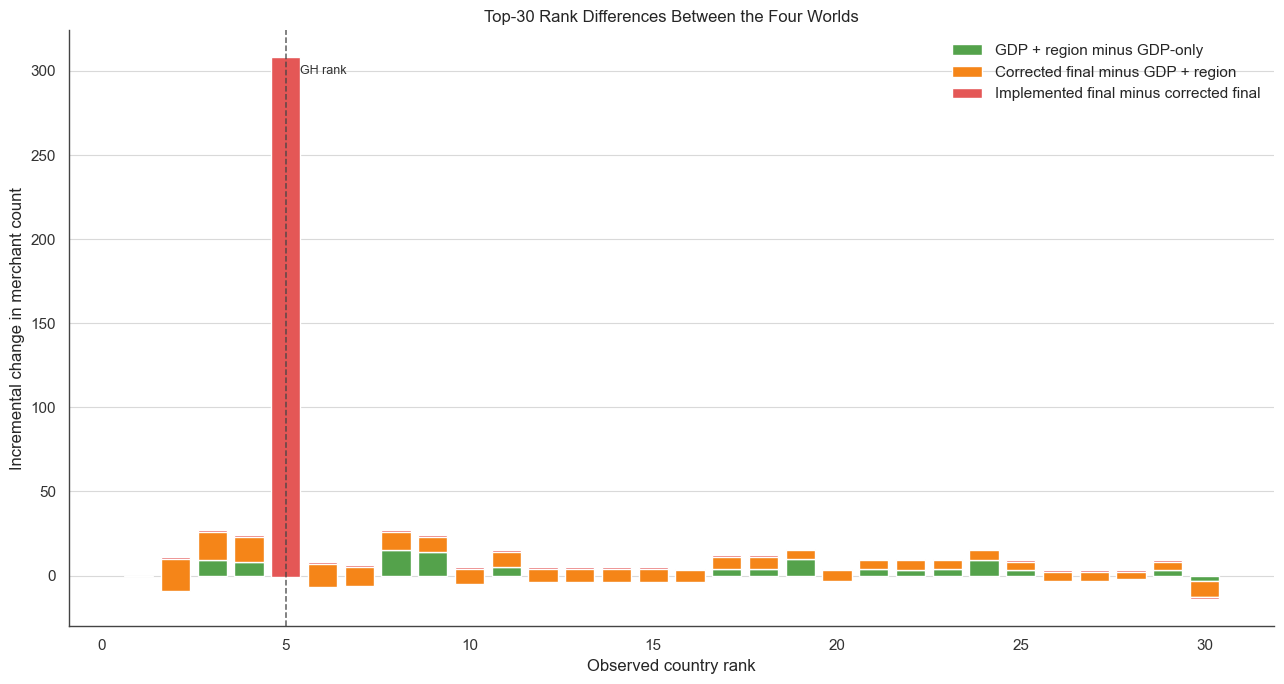

In [40]:
# Convert the world transitions into incremental deltas so the top-end refinement becomes visible by rank.
merchant_allocation_rank_diff_df = merchant_allocation_worlds_df.sort_values("observed_count", ascending=False).head(30).copy()
merchant_allocation_rank_diff_df["rank"] = np.arange(1, len(merchant_allocation_rank_diff_df) + 1)
merchant_allocation_rank_diff_df["regional_delta"] = merchant_allocation_rank_diff_df["gdp_region_count"] - merchant_allocation_rank_diff_df["gdp_only_count"]
merchant_allocation_rank_diff_df["heavytail_delta"] = merchant_allocation_rank_diff_df["corrected_final_count"] - merchant_allocation_rank_diff_df["gdp_region_count"]
merchant_allocation_rank_diff_df["artifact_delta"] = merchant_allocation_rank_diff_df["implemented_final_count"] - merchant_allocation_rank_diff_df["corrected_final_count"]

fig, ax = plt.subplots(figsize=(13, 7))
ax.bar(merchant_allocation_rank_diff_df["rank"], merchant_allocation_rank_diff_df["regional_delta"], color=EFFECT_COLORS["Regional uplift"], label="GDP + region minus GDP-only")
ax.bar(merchant_allocation_rank_diff_df["rank"], merchant_allocation_rank_diff_df["heavytail_delta"], bottom=merchant_allocation_rank_diff_df["regional_delta"], color=EFFECT_COLORS["Heavy-tail uplift"], label="Corrected final minus GDP + region")
ax.bar(merchant_allocation_rank_diff_df["rank"], merchant_allocation_rank_diff_df["artifact_delta"], bottom=merchant_allocation_rank_diff_df["regional_delta"] + merchant_allocation_rank_diff_df["heavytail_delta"], color=EFFECT_COLORS["Implementation artifact"], label="Implemented final minus corrected final")

gh_rank = int(merchant_allocation_rank_diff_df.loc[merchant_allocation_rank_diff_df["iso"] == "GH", "rank"].iloc[0])
ax.axvline(gh_rank, color="#444444", linestyle="--", linewidth=1.1, alpha=0.85)
ax.text(gh_rank + 0.4, ax.get_ylim()[1] * 0.92, "GH rank", fontsize=9, color="#333333")

ax.set_title("Top-30 Rank Differences Between the Four Worlds")
ax.set_xlabel("Observed country rank")
ax.set_ylabel("Incremental change in merchant count")
style_axes(ax, grid_x=False, grid_y=True)
ax.legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


This rank-difference view translates the four worlds into actual increments, which is what makes the policy mechanics readable. The green regional bars show that the regional step is selective rather than universal; it materially helps a subset of countries rather than the whole top end equally. The orange heavy-tail bars are broader and more systematic, which confirms that the heavy-tail step is the main intended policy mechanism that intensifies concentration after GDP and region have already shaped the world.

The red implemented-minus-corrected bars then show where implementation diverges from intended policy. The marked `GH` rank is the clearest statistical rupture in the entire section: its artifact bar towers above everything else, while the rest of the top-30 countries show almost no implementation distortion by comparison. So this chart is doing more than confirming there is a `GH` problem. It shows that the policy itself has a staged and intelligible structure, and that the builder artifact is sharply localized rather than spread across the whole leading-country set.


**Top 15 Countries**

Read the leading countries directly across the four worlds.


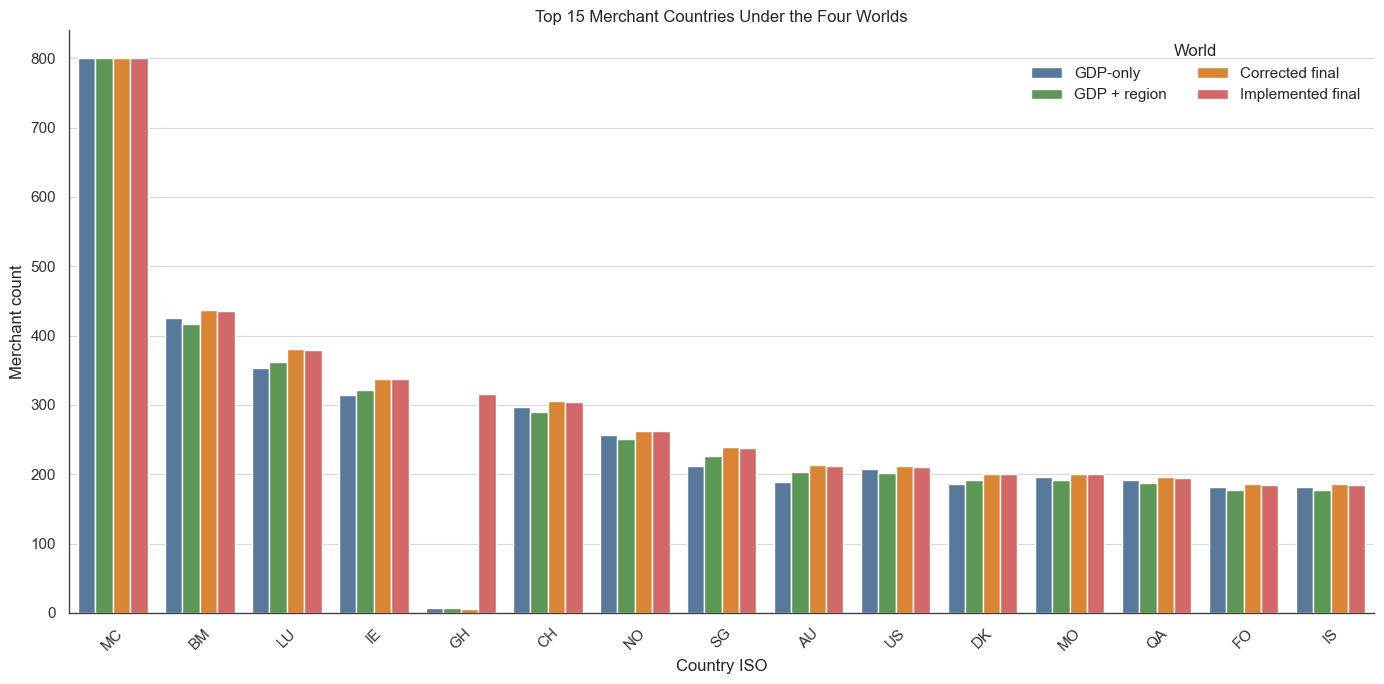

In [41]:
# Restrict to the leading observed countries so we can read the four-world differences directly.
merchant_allocation_top15_df = merchant_allocation_worlds_df.sort_values("observed_count", ascending=False).head(15).copy()
merchant_allocation_top15_long_df = merchant_allocation_top15_df.melt(
    id_vars=["iso"],
    value_vars=["gdp_only_count", "gdp_region_count", "corrected_final_count", "implemented_final_count"],
    var_name="world",
    value_name="merchant_count",
)
merchant_allocation_top15_long_df["world"] = merchant_allocation_top15_long_df["world"].map({
    "gdp_only_count": "GDP-only",
    "gdp_region_count": "GDP + region",
    "corrected_final_count": "Corrected final",
    "implemented_final_count": "Implemented final",
})

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=merchant_allocation_top15_long_df,
    x="iso",
    y="merchant_count",
    hue="world",
    palette=WORLD_COLORS,
    ax=ax,
)

ax.set_title("Top 15 Merchant Countries Under the Four Worlds")
ax.set_xlabel("Country ISO")
ax.set_ylabel("Merchant count")
ax.tick_params(axis="x", rotation=45)
style_axes(ax, grid_x=False, grid_y=True)
ax.legend(title="World", frameon=False, ncol=2)
plt.tight_layout()
plt.show()


This top-country comparison makes the four-world differences concrete at the country level. It shows that the leading merchant jurisdictions are not all being created in the same way. `MC` is essentially fixed across all four worlds, which means its dominance is already secured by the GDP-weighted base and the cap structure. Countries such as `BM`, `LU`, `IE`, `CH`, `NO`, `SG`, `AU`, and `US` follow a more layered path: GDP-only already places them high, the regional step helps some of them selectively, and the full policy then adds another concentrated uplift. That is the policy behaving as designed.

The country that breaks this pattern is `GH`. In the first three worlds it is essentially absent as a major merchant jurisdiction, but under the implemented final path it jumps into the top-country set. That visual contrast is important because it separates two kinds of top-country prominence. Some countries are genuinely top countries under the authored macro-allocation logic; `GH` becomes a top country only because of the current builder implementation. So this chart is not just comparing bar heights. It is sorting the top-country list into policy-authored countries and implementation-authored anomaly.


**Step Contributions**

Decompose how the regional step, the heavy-tail step, and the implementation artifact move the leading countries.


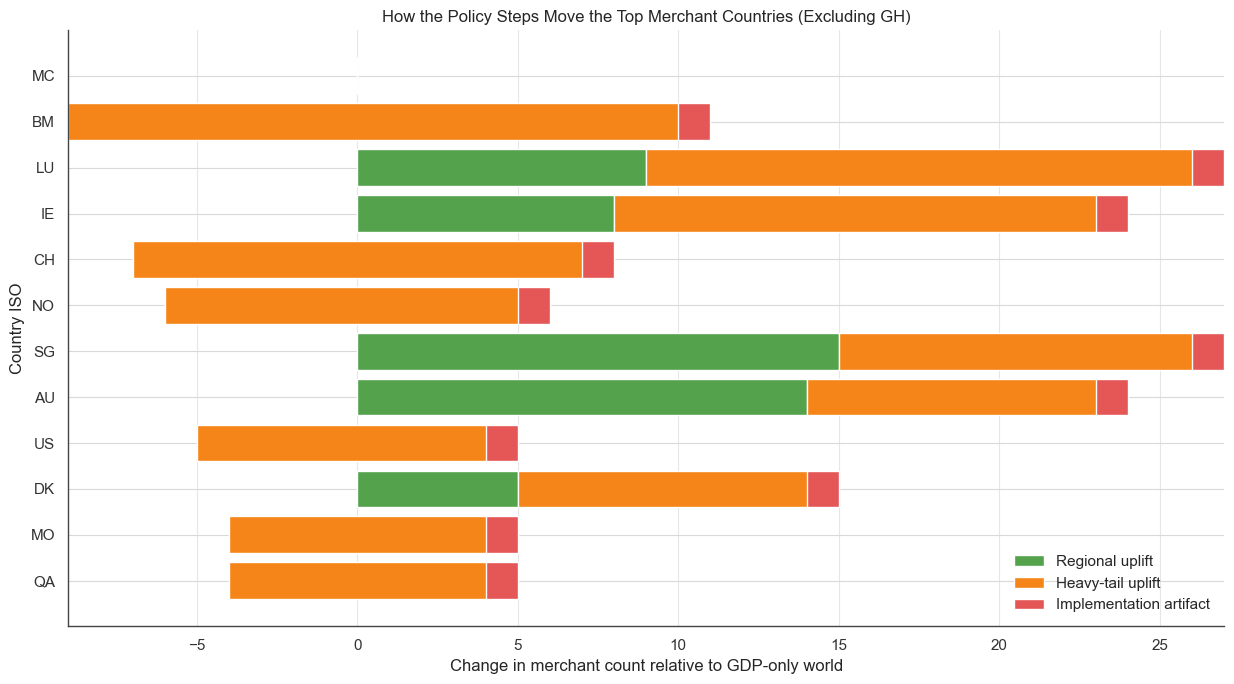

In [42]:
# Remove GH here because its implementation artifact is so large that it flattens the rest of the chart.
merchant_allocation_step_effects_df = (
    merchant_allocation_worlds_df.loc[merchant_allocation_worlds_df["iso"] != "GH", ["iso", "observed_count", "regional_uplift", "heavytail_uplift", "implementation_artifact"]]
    .sort_values("observed_count", ascending=False)
    .head(12)
    .copy()
)

fig, ax = plt.subplots(figsize=(12.5, 7))
left = np.zeros(len(merchant_allocation_step_effects_df))
for column, label in [("regional_uplift", "Regional uplift"), ("heavytail_uplift", "Heavy-tail uplift"), ("implementation_artifact", "Implementation artifact")]:
    values = merchant_allocation_step_effects_df[column].to_numpy()
    ax.barh(merchant_allocation_step_effects_df["iso"], values, left=left, color=EFFECT_COLORS[label], label=label)
    left = left + values

ax.set_title("How the Policy Steps Move the Top Merchant Countries (Excluding GH)")
ax.set_xlabel("Change in merchant count relative to GDP-only world")
ax.set_ylabel("Country ISO")
style_axes(ax, grid_x=True, grid_y=True)
ax.legend(frameon=False, loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


This step-effects view answers the policy question in additive form: once we start from the GDP-only world, which later layers are doing the actual moving? The green regional component is selective and intelligible. It visibly benefits the APAC and EU-linked countries we would expect, such as `SG`, `AU`, `LU`, and `IE`. The orange heavy-tail component is the stronger and more systematic source of extra concentration. It adds to a broad set of already-strong countries, which means the policy is not merely identifying rich countries; it is deliberately intensifying the top end after the GDP and regional stages have already done their work.

The small red implementation-artifact segments for these non-`GH` countries are also important. They tell us that, for most of the leading jurisdictions, the implemented builder is only slightly different from the corrected final policy. So outside the `GH` case, the merchant-country world we see is mostly a faithful realisation of the intended policy. That matters for the investigation because it means we should not overreact and treat the whole top-country structure as corrupted. The dominant pattern for these countries is still authored policy logic, with only minor implementation drift.


**GH Spotlight**

Isolate `GH`, because this is the country where the implemented path diverges most sharply from the intended policy worlds.


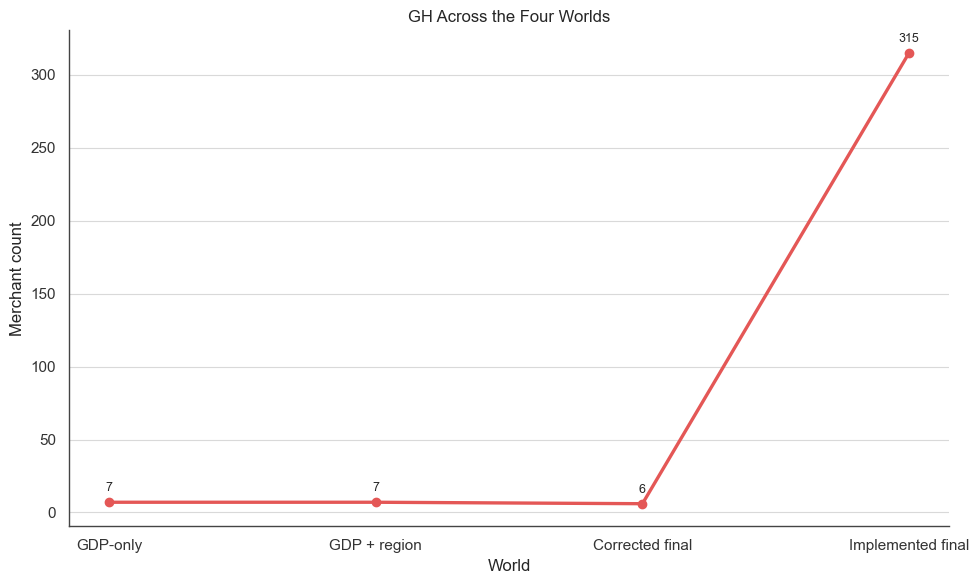

In [43]:
# Isolate GH because it is the country where the implemented path diverges most visibly from the intended policy worlds.
gh_row = merchant_allocation_worlds_df.loc[merchant_allocation_worlds_df["iso"] == "GH"].iloc[0]
gh_worlds = ["GDP-only", "GDP + region", "Corrected final", "Implemented final"]
gh_values = [gh_row["gdp_only_count"], gh_row["gdp_region_count"], gh_row["corrected_final_count"], gh_row["implemented_final_count"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(gh_worlds, gh_values, marker="o", linewidth=2.4, color="#E45756")
for x, y in zip(gh_worlds, gh_values):
    ax.annotate(f"{int(y)}", (x, y), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=9)

ax.set_title("GH Across the Four Worlds")
ax.set_xlabel("World")
ax.set_ylabel("Merchant count")
style_axes(ax, grid_x=False, grid_y=True)
plt.tight_layout()
plt.show()


This is the cleanest single-country diagnostic in the whole block. `GH` is flat and tiny under the GDP-only world, it stays flat after the regional step, and it remains flat under the corrected final policy. Then the implemented final path sends it sharply upward to `315`. So the visual message is unambiguous: `GH` is not a rich-country effect, not a regional-uplift effect, and not even a legitimate heavy-tail winner under the intended final policy. It is a product of the builder's implemented reconciliation step.

That matters beyond `GH` itself. Earlier in the investigation, `GH` was the awkward low-bucket exception that the GDP and bucket surfaces could not explain. This chart closes that loop. It shows where the exception enters the world: not in the governed macro artefacts, but in the transition from intended policy to implemented builder output. In the context of `1A.S0`, that means the merchant parquet carries both genuine policy structure and a visible pre-engine implementation artifact, and `GH` is the clearest proof of that distinction.


**Builder Artifact**

Compare the implemented final world directly against the corrected final policy to see where the builder changes country counts.


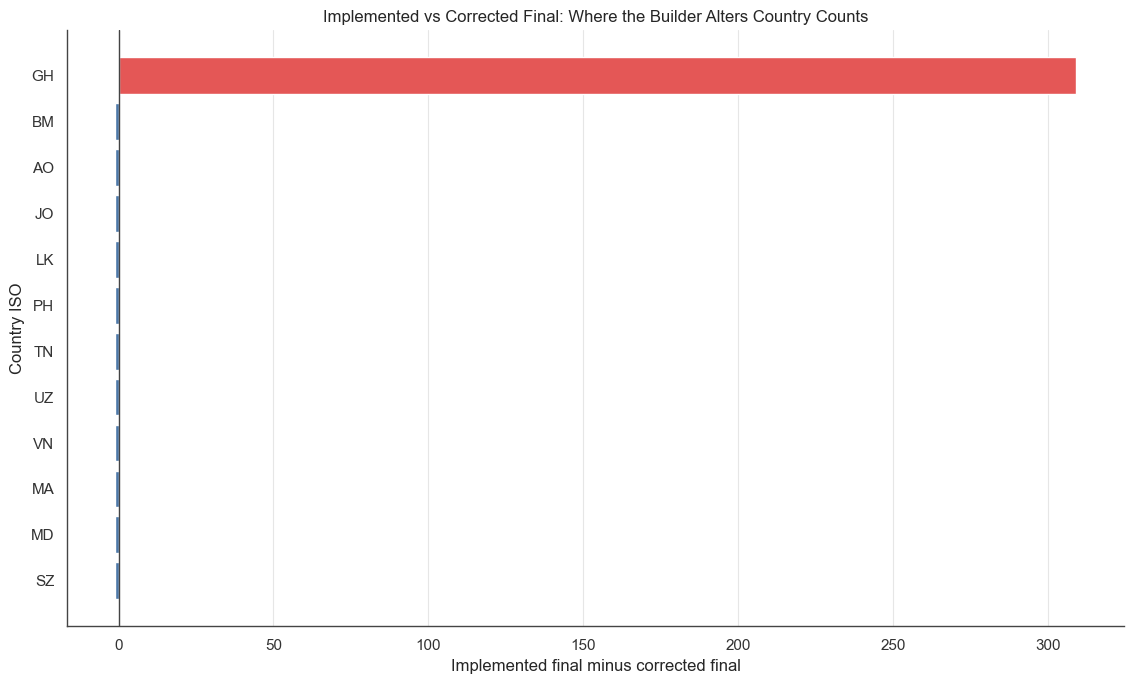

In [44]:
# Compare the implemented builder output directly against the corrected final policy to isolate builder-side drift.
merchant_allocation_artifact_df = merchant_allocation_worlds_df[["iso", "implemented_final_count", "corrected_final_count"]].copy()
merchant_allocation_artifact_df["artifact_delta"] = merchant_allocation_artifact_df["implemented_final_count"] - merchant_allocation_artifact_df["corrected_final_count"]
merchant_allocation_artifact_df = merchant_allocation_artifact_df.loc[merchant_allocation_artifact_df["artifact_delta"] != 0].sort_values("artifact_delta", ascending=False)
merchant_allocation_artifact_display_df = merchant_allocation_artifact_df.head(12).copy()

fig, ax = plt.subplots(figsize=(11.5, 7))
colors = ["#E45756" if value > 0 else "#4C78A8" for value in merchant_allocation_artifact_display_df["artifact_delta"]]
ax.barh(merchant_allocation_artifact_display_df["iso"], merchant_allocation_artifact_display_df["artifact_delta"], color=colors)
ax.axvline(0, color="#444444", linewidth=1.0)
ax.set_title("Implemented vs Corrected Final: Where the Builder Alters Country Counts")
ax.set_xlabel("Implemented final minus corrected final")
ax.set_ylabel("Country ISO")
style_axes(ax, grid_x=True, grid_y=False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


This artifact view answers the narrow builder question directly: where does the implemented final world differ from the corrected final policy world? Visually, almost the entire chart is one story. `GH` dominates the difference surface, while every other visible country sits almost flat by comparison. So the implementation problem is not a diffuse wobble across many leading countries; it is a single-country distortion with overwhelming weight.

That is important for the broader investigation because it prevents us from over-reading the policy as broadly corrupted. The merchant-country world is still largely policy-authored. What this chart shows is that one implementation choice in the builder is injecting a large outlier into an otherwise coherent authoring path. In other words, the current merchant parquet is not globally unreliable; it is locally distorted in a very specific and highly visible way.


**Builder Drift Outside GH**

Remove `GH` so the residual builder drift on the rest of the country world becomes readable.


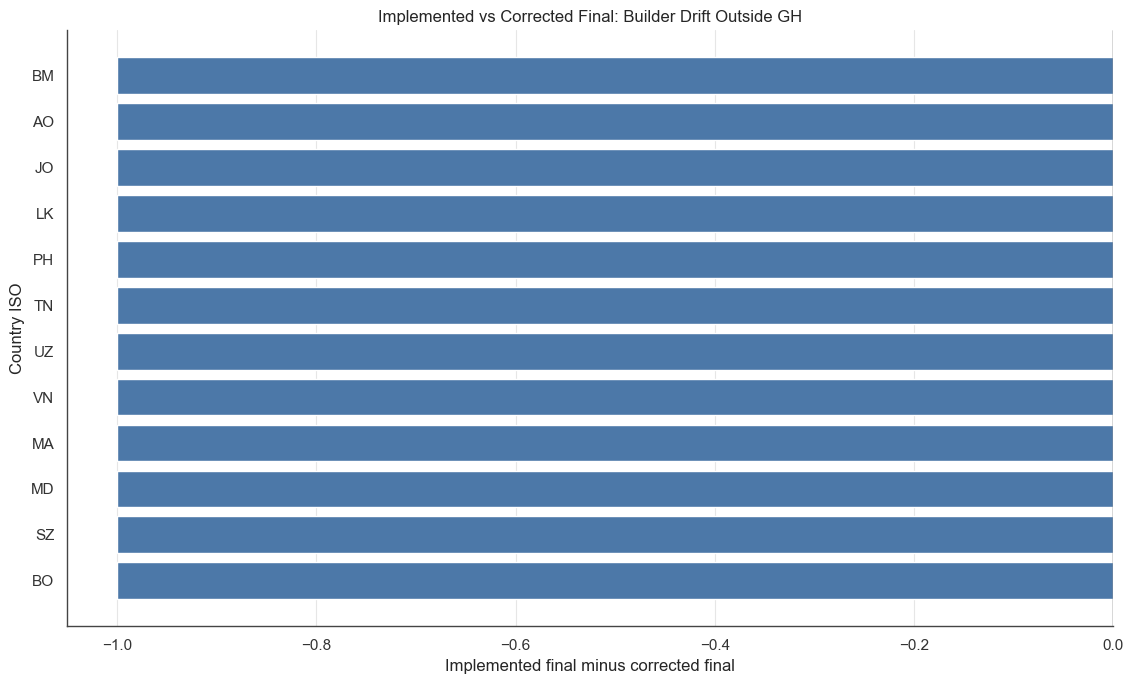

In [45]:
# Remove GH so the residual builder drift on the rest of the leading countries becomes visible.
merchant_allocation_artifact_ex_gh_df = merchant_allocation_artifact_df.loc[merchant_allocation_artifact_df["iso"] != "GH"].head(12).copy()

fig, ax = plt.subplots(figsize=(11.5, 7))
colors = ["#E45756" if value > 0 else "#4C78A8" for value in merchant_allocation_artifact_ex_gh_df["artifact_delta"]]
ax.barh(merchant_allocation_artifact_ex_gh_df["iso"], merchant_allocation_artifact_ex_gh_df["artifact_delta"], color=colors)
ax.axvline(0, color="#444444", linewidth=1.0)
ax.set_title("Implemented vs Corrected Final: Builder Drift Outside GH")
ax.set_xlabel("Implemented final minus corrected final")
ax.set_ylabel("Country ISO")
style_axes(ax, grid_x=True, grid_y=False)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


Once `GH` is removed, the remaining builder drift becomes legible. The striking result is how small and regular it is. The leading countries shown here are almost all shifted by exactly `-1` relative to the corrected final policy. That means the builder is not randomly perturbing the rest of the country world in large or uneven ways. Outside the `GH` case, the implemented final world is effectively the corrected final world with a nearly uniform one-count shortfall spread across the remaining countries.

This matters because it sharpens the policy diagnosis. The implemented builder is not creating many country-specific anomalies; it is creating one major anomaly and then a near-uniform residual offset elsewhere. So when we interpret the top-country structure for `1A.S0`, we should treat the non-`GH` leading countries as substantially faithful to the intended policy, while isolating `GH` as the country where the implemented path genuinely changes the statistical story.


**What This Shows:** This block now gives a fuller answer to what the merchant-allocation policy is doing before `1A.S0` ingests the merchant universe. GDP-per-capita weighting creates the base top-heavy country world, the regional multipliers selectively strengthen favored blocs, and the heavy-tail step further intensifies already-strong countries. So the merchant-country concentration we observed earlier is genuinely policy-authored rather than an accidental property of the parquet. The additional plots make that staged construction visible rather than implied. They show the top end separating progressively across the worlds, and they show the incremental contribution of each policy layer by rank.

At the same time, the added artifact views sharpen the second half of the story. The implemented builder does not broadly scramble the intended policy world. Instead, it introduces one dominant distortion through `GH`, while the rest of the countries sit very close to the corrected final policy, largely with a near-uniform one-count shortfall. So the merchant parquet carries two truths at once: a country-allocation world that is substantively authored by governed policy, and a sharply localized pre-engine implementation artifact that materially inflates one country. That is the distinction we now need to carry forward as we continue deeper into `1A`.
